In [ ]:
import pandas as pd
import os
from sklearn.model_selection import train_test_split
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import classification_report, accuracy_score

# Ton code de chargement ici (celui que tu m'as donné)
# ... (Partie montage Drive et création du df) ...

In [ ]:
import os
import pandas as pd
from google.colab import drive

# 1. Montage du Drive
drive.mount('/content/drive')

# 2. Définition du chemin
base_path = "/content/drive/MyDrive/WOS11967/"

# 3. Chargement direct des données
with open(os.path.join(base_path, "X.txt"), "r", encoding="utf-8") as f:
    X_data = f.read().splitlines()

with open(os.path.join(base_path, "YL1.txt"), "r", encoding="utf-8") as f:
    YL1_data = f.read().splitlines()
with open(os.path.join(base_path, "YL2.txt"), "r", encoding="utf-8") as f:
      YL2_data = f.read().splitlines()
with open(os.path.join(base_path, "Y.txt"), "r", encoding="utf-8") as f:
      Y_data = f.read().splitlines()

# 4. Création du DataFrame (Le prof veut prédire le premier seulement : YL1)
df = pd.DataFrame({
    "texte": X_data,
    "YL1": YL1_data,
    "YL2": YL2_data,
     "Y": Y_data
})

print("Chargement réussi !")
print(df)

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).
Chargement réussi !
                                                   texte YL1 YL2   Y
0      The aim of this study was to investigate (a) t...   2   2  10
1      The detection of negative emotions through dai...   0   1   1
2      DNA/RNA sequencing has recently become a prima...   6   1  29
3      Primary European car-makers agree on a 48 V em...   3   3  16
4      Background: Chronic alcohol intake impacts ski...   5   0  23
...                                                  ...  ..  ..  ..
11962  Dense motion field estimation is a key compute...   0   0   0
11963  Background: The Generation Scotland: Scottish ...   6   4  32
11964  Purpose The application of organic and inorgan...   4   4  22
11965  The pathophysiological changes associated with...   6   2  30
11966  During the last decades photogrammetric comput...   0   0   0

[11967 rows x 4 column

In [ ]:
# Exemple : récupérer un texte représentatif pour chaque classe
classes_YL1 = sorted(df['YL1'].unique())
representatifs = {c: df[df['YL1']==c]['texte'].iloc[0][:50]+"..." for c in classes_YL1}
print(representatifs)


{'0': 'The detection of negative emotions through daily a...', '1': 'Transient analysis of Switching Power Converter (S...', '2': 'The aim of this study was to investigate (a) the b...', '3': 'Primary European car-makers agree on a 48 V embedd...', '4': 'Service reputation is a key factor for service sel...', '5': 'Background: Chronic alcohol intake impacts skin di...', '6': 'DNA/RNA sequencing has recently become a primary w...'}


In [ ]:
import pandas as pd

# Récupérer un texte représentatif pour chaque classe YL2
classes_YL1 = sorted(df['YL1'].unique())
representatifs_YL1 = {c: df[df['YL1']==c]['texte'].iloc[0][:50]+"..." for c in classes_YL1}

# Transformer en DataFrame pour un tableau lisible
tableau_YL1 = pd.DataFrame({
    "Classe (YL1)": representatifs_YL1.keys(),
    "Exemple de texte": representatifs_YL1.values()
})

# Afficher le tableau
print(tableau_YL1)


  Classe (YL1)                                   Exemple de texte
0            0  The detection of negative emotions through dai...
1            1  Transient analysis of Switching Power Converte...
2            2  The aim of this study was to investigate (a) t...
3            3  Primary European car-makers agree on a 48 V em...
4            4  Service reputation is a key factor for service...
5            5  Background: Chronic alcohol intake impacts ski...
6            6  DNA/RNA sequencing has recently become a prima...


In [ ]:
#Exemple : récupérer un texte représentatif pour chaque classe
classes_YL2 = sorted(df['YL2'].unique())
representatifs = {c: df[df['YL2']==c]['texte'].iloc[0][:50]+"..." for c in classes_YL2}
print(representatifs)

{'0': 'Background: Chronic alcohol intake impacts skin di...', '1': 'The detection of negative emotions through daily a...', '2': 'The aim of this study was to investigate (a) the b...', '3': 'Primary European car-makers agree on a 48 V embedd...', '4': 'FH98 digital scheduling system can realize the fun...'}


In [ ]:
import pandas as pd

# Récupérer un texte représentatif pour chaque classe YL2
classes_YL2 = sorted(df['YL2'].unique())
representatifs_YL2 = {c: df[df['YL2']==c]['texte'].iloc[0][:50]+"..." for c in classes_YL2}

# Transformer en DataFrame pour un tableau lisible
tableau_YL2 = pd.DataFrame({
    "Classe (YL2)": representatifs_YL2.keys(),
    "Exemple de texte": representatifs_YL2.values()
})

# Afficher le tableau
print(tableau_YL2)


  Classe (YL2)                                   Exemple de texte
0            0  Background: Chronic alcohol intake impacts ski...
1            1  The detection of negative emotions through dai...
2            2  The aim of this study was to investigate (a) t...
3            3  Primary European car-makers agree on a 48 V em...
4            4  FH98 digital scheduling system can realize the...


In [ ]:
#Exemple : récupérer un texte représentatif pour chaque classe
classes_Y = sorted(df['Y'].unique())
representatifs = {c: df[df['Y']==c]['texte'].iloc[0][:50]+"..." for c in classes_Y}
print(representatifs)

{'0': 'The ability to automatically recognize human faces...', '1': 'The detection of negative emotions through daily a...', '10': 'The aim of this study was to investigate (a) the b...', '11': 'People can accurately assess various personality t...', '12': 'Whether children share in anticipation of future b...', '13': 'An analytical model for the silicon-on-insulator (...', '14': 'This work presents the application of the comprehe...', '15': 'This paper deals with the motion analysis of skier...', '16': 'Primary European car-makers agree on a 48 V embedd...', '17': 'Experimental data from multiple studies show the c...', '18': 'Service reputation is a key factor for service sel...', '19': 'In the present study, blast furnace slag in granul...', '2': 'With the advent of new technologies and various se...', '20': 'Supervised classification methods have been widely...', '21': 'Urban stormwater runoff is both a significant poll...', '22': 'An intensification of agriculture in the Brazilian

In [ ]:
import pandas as pd

# Récupérer un texte représentatif pour chaque classe YL2
classes_Y = sorted(df['Y'].unique())
representatifs_Y = {c: df[df['Y']==c]['texte'].iloc[0][:50]+"..." for c in classes_Y}

# Transformer en DataFrame pour un tableau lisible
tableau_Y = pd.DataFrame({
    "Classe (Y)": representatifs_Y.keys(),
    "Exemple de texte": representatifs_Y.values()
})

# Afficher le tableau
print(tableau_Y)


   Classe (Y)                                   Exemple de texte
0           0  The ability to automatically recognize human f...
1           1  The detection of negative emotions through dai...
2          10  The aim of this study was to investigate (a) t...
3          11  People can accurately assess various personali...
4          12  Whether children share in anticipation of futu...
5          13  An analytical model for the silicon-on-insulat...
6          14  This work presents the application of the comp...
7          15  This paper deals with the motion analysis of s...
8          16  Primary European car-makers agree on a 48 V em...
9          17  Experimental data from multiple studies show t...
10         18  Service reputation is a key factor for service...
11         19  In the present study, blast furnace slag in gr...
12          2  With the advent of new technologies and variou...
13         20  Supervised classification methods have been wi...
14         21  Urban stor

In [ ]:
# Remplacer 'df' par le nom de ta variable DataFrame
valeur_y = 10
resultat = df[df['Y'] == valeur_y]

print(f"Lignes correspondant à Y = {valeur_y} :")
print(resultat)

Lignes correspondant à Y = 10 :
Empty DataFrame
Columns: [texte, YL1, YL2, Y]
Index: []


In [ ]:
df["YL1"].unique()


array(['2', '0', '6', '3', '5', '4', '1'], dtype=object)

In [ ]:
# Ceci te montre toutes les combinaisons uniques
print(df.groupby('Y')[['YL1', 'YL2']].value_counts())

Y   YL1  YL2
0   0    0      298
1   0    1      301
10  2    2      391
         3        1
11  2    3      393
12  2    4      388
13  3    0      371
14  3    1      402
15  3    2      346
16  3    3      420
17  3    4      386
18  4    0      410
19  4    1      423
2   0    2      300
20  4    2      384
21  4    3      441
22  4    4      449
23  5    0      309
24  5    1      357
25  5    2      368
26  5    3      321
27  5    4      262
28  6    0      351
29  6    1      340
3   0    3      300
30  6    2      401
31  6    3      335
32  6    4      301
4   0    4      300
5   1    0      300
6   1    2      353
         3       53
7   1    4      426
8   2    0      389
9   2    1      397
Name: count, dtype: int64


Dans la grande majorité des cas, une valeur de Y correspond à une seule combinaison de (YL1, YL2). Par exemple :Pour $Y = 11$, tu as toujours $YL1=2$ et $YL2=3$ (393 fois).Pour $Y = 12$, tu as toujours $YL1=2$ et $YL2=4$ (388 fois).2. Les "Anomalies" ou VariationsRegarde attentivement les valeurs Y = 10 et Y = 6. Ce sont les endroits où la règle change :Pour Y = 10 : * Dans 391 cas, tu as $(2, 2)$.Mais dans 1 cas, tu as $(2, 3)$.Cela signifie que pour $Y=10$, les modalités ne sont pas strictement identiques à 100%.Pour Y = 6 :Dans 353 cas, tu as $(1, 2)$.Mais dans 53 cas, tu as $(1, 3)$.Ici, la variation est beaucoup plus forte.

In [ ]:
# 1. On s'assure que tout est bien au format numérique
df['Y'] = df['Y'].astype(int)
df['YL1'] = df['YL1'].astype(int)
df['YL2'] = df['YL2'].astype(int)

# 2. On extrait les anomalies (celles que tu as vues dans tes résultats)
# Pour Y = 10, la modalité rare était YL2 = 3
anomalie_10 = df[(df['Y'] == 10) & (df['YL2'] == 3)]

# Pour Y = 6, la modalité rare était YL2 = 3 (il y en a 53)
anomalie_6 = df[(df['Y'] == 6) & (df['YL2'] == 3)]

print("--- Anomalie Y=10 ---")
print(anomalie_10)

print("\n--- Anomalies Y=6 (53 lignes) ---")
print(anomalie_6.head()) # .head() pour ne pas tout afficher

--- Anomalie Y=10 ---
                                                   texte  YL1  YL2   Y
11945  Major basketball competitions are characterize...    2    3  10

--- Anomalies Y=6 (53 lignes) ---
                                                  texte  YL1  YL2  Y
214   Purpose - The resistance, capacitance and indu...    1    3  6
368   It is well known that optimizing network topol...    1    3  6
395   This paper presents three new contributions to...    1    3  6
777   The control of tilt/twist angles during ion im...    1    3  6
1079  It is known that given a directed graph E and ...    1    3  6


In [ ]:
# Identification des conflits
conflits = df.groupby('Y').filter(lambda x: x[['YL1', 'YL2']].drop_duplicates().shape[0] > 1)

print(f"Nombre de lignes en conflit : {len(conflits)}")
print("Exemple de conflit pour Y=6 :")
print(conflits[conflits['Y'] == 6][['texte', 'YL1', 'YL2', 'Y']].head())

Nombre de lignes en conflit : 798
Exemple de conflit pour Y=6 :
                                                texte  YL1  YL2  Y
7   Transient analysis of Switching Power Converte...    1    2  6
8   The assessment and prevention of floods requir...    1    2  6
16  The concept of energy is widely employed in in...    1    2  6
24  There are three main magnet systems in Wendels...    1    2  6
33  The paper presents application of particle swa...    1    2  6


In [ ]:
# On garde uniquement les lignes qui correspondent à la combinaison la plus fréquente pour chaque Y
df_propre = df.groupby('Y').apply(lambda x: x[
    (x['YL1'] == x['YL1'].mode()[0]) &
    (x['YL2'] == x['YL2'].mode()[0])
]).reset_index(drop=True)

print(f"Ancien total : {len(df)} lignes")
print(f"Nouveau total : {len(df_propre)} lignes")

Ancien total : 11967 lignes
Nouveau total : 11913 lignes


/tmp/ipython-input-535924807.py:2: DeprecationWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  df_propre = df.groupby('Y').apply(lambda x: x[


In [ ]:
# On remplace directement 'df' par sa version nettoyée
df = df.groupby('Y').apply(lambda x: x[
    (x['YL1'] == x['YL1'].mode()[0]) &
    (x['YL2'] == x['YL2'].mode()[0])
]).reset_index(drop=True)

# MAINTENANT, vérifie :
print(df.groupby('Y')[['YL1', 'YL2']].value_counts())

Y   YL1  YL2
0   0    0      298
1   0    1      301
2   0    2      300
3   0    3      300
4   0    4      300
5   1    0      300
6   1    2      353
7   1    4      426
8   2    0      389
9   2    1      397
10  2    2      391
11  2    3      393
12  2    4      388
13  3    0      371
14  3    1      402
15  3    2      346
16  3    3      420
17  3    4      386
18  4    0      410
19  4    1      423
20  4    2      384
21  4    3      441
22  4    4      449
23  5    0      309
24  5    1      357
25  5    2      368
26  5    3      321
27  5    4      262
28  6    0      351
29  6    1      340
30  6    2      401
31  6    3      335
32  6    4      301
Name: count, dtype: int64


/tmp/ipython-input-1689064733.py:2: DeprecationWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  df = df.groupby('Y').apply(lambda x: x[


In [ ]:
# ────────────────────────────────────────────────────────────────
# NLTK - Préparation (un seul bloc - à placer tout en haut après les imports généraux)
# ────────────────────────────────────────────────────────────────
import nltk
import re
from nltk.corpus import stopwords
from nltk.tokenize import word_tokenize
from nltk.stem import WordNetLemmatizer

# Liste des ressources nécessaires (version sûre et complète)
nltk_resources = [
    'punkt',       # Tokenization de base
    'punkt_tab',   # Nécessaire sur les versions récentes de NLTK/Colab
    'wordnet',     # Pour la lemmatisation
    'omw-1.4',     # Amélioration du lemmatizer en anglais
    'stopwords'    # Liste des mots vides
]

# Téléchargement intelligent (seulement si absent)
for resource in nltk_resources:
    try:
        if resource in ['stopwords', 'wordnet', 'omw-1.4']:
            nltk.data.find(f'corpora/{resource}')
        else:
            nltk.data.find(f'tokenizers/{resource}')
    except LookupError:
        nltk.download(resource, quiet=True)

# Outils globaux (à utiliser partout dans le notebook)
STOP_WORDS = set(stopwords.words('english'))
lemmatizer = WordNetLemmatizer()

In [ ]:
def preprocess_text_nltk(text, stop_words=STOP_WORDS, lemmatizer=lemmatizer):
    # Sécuriser type
    if not isinstance(text, str):
        text = str(text)

    # Normalisation
    txt = text.lower()
    txt = re.sub(r'\d+', ' ', txt)
    txt = re.sub(r'[^\w\s]', ' ', txt)

    # Tokenisation robuste
    try:
        tokens = word_tokenize(txt)
    except LookupError:
        # Téléchargement en dernier recours puis nouvel essai
        ensure_nltk("punkt", "tokenizers")
        ensure_nltk("punkt_tab", "tokenizers")
        try:
            tokens = word_tokenize(txt)
        except Exception:
            # Fallback regex si NLTK échoue encore
            tokens = re.findall(r"\b\w+\b", txt)

    # Filtrage + lemmatisation
    tokens = [lemmatizer.lemmatize(t) for t in tokens if t not in stop_words and len(t) > 1]

    return " ".join(tokens)

# Application au DataFrame (suppose df et df['texte'] existent)
df['texte_clean'] = df['texte'].apply(preprocess_text_nltk)
print(df[['texte', 'texte_clean']].head())


                                               texte  \
0  The ability to automatically recognize human f...   
1  Many computer vision problems involve explorin...   
2  Maintaining multivariate calibrations involves...   
3  As a powerful nonparametric Bayesian model, th...   
4  The objective of this study is to create compu...   

                                         texte_clean  
0  ability automatically recognize human face bas...  
1  many computer vision problem involve exploring...  
2  maintaining multivariate calibration involves ...  
3  powerful nonparametric bayesian model infinite...  
4  objective study create computer vision algorit...  


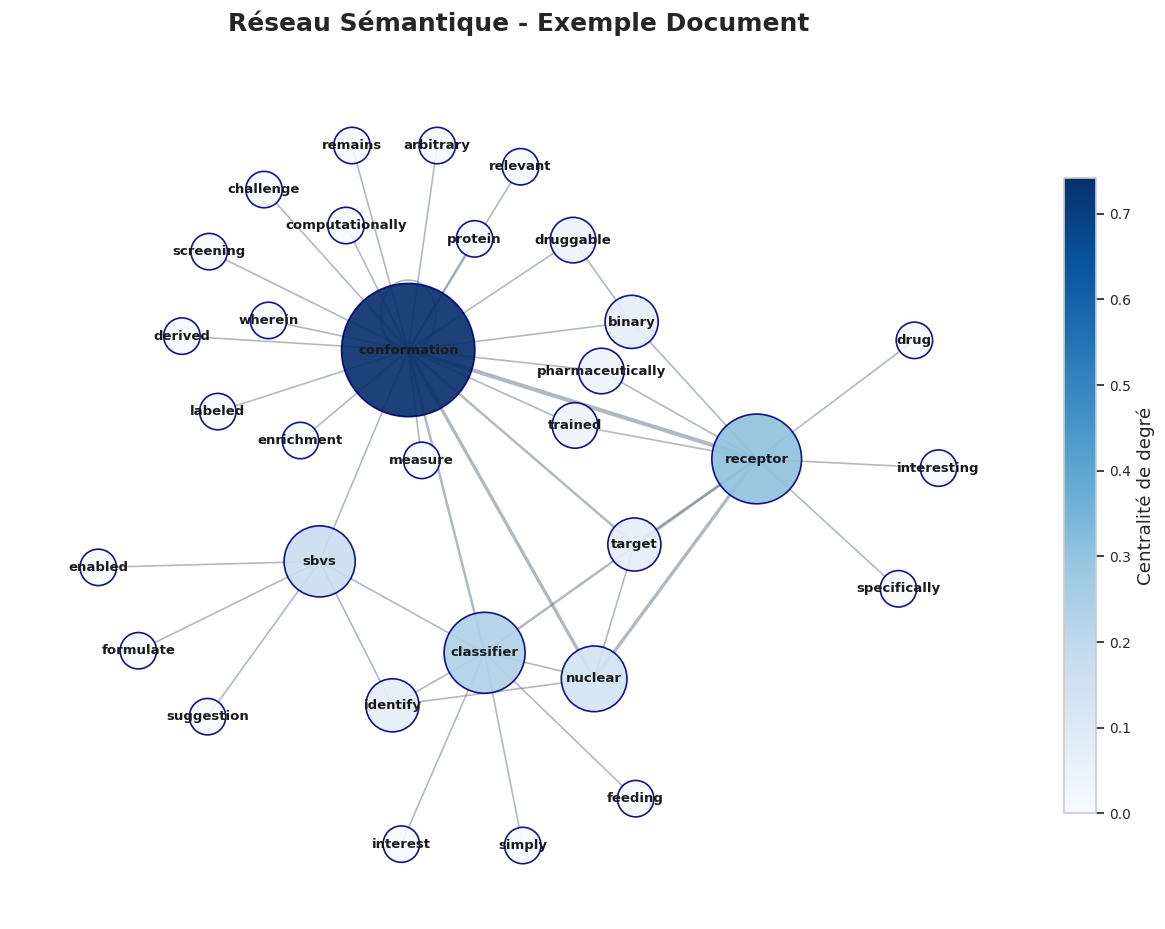

Graphe sauvegardé : figures/reseau_classe_YL1_5.png


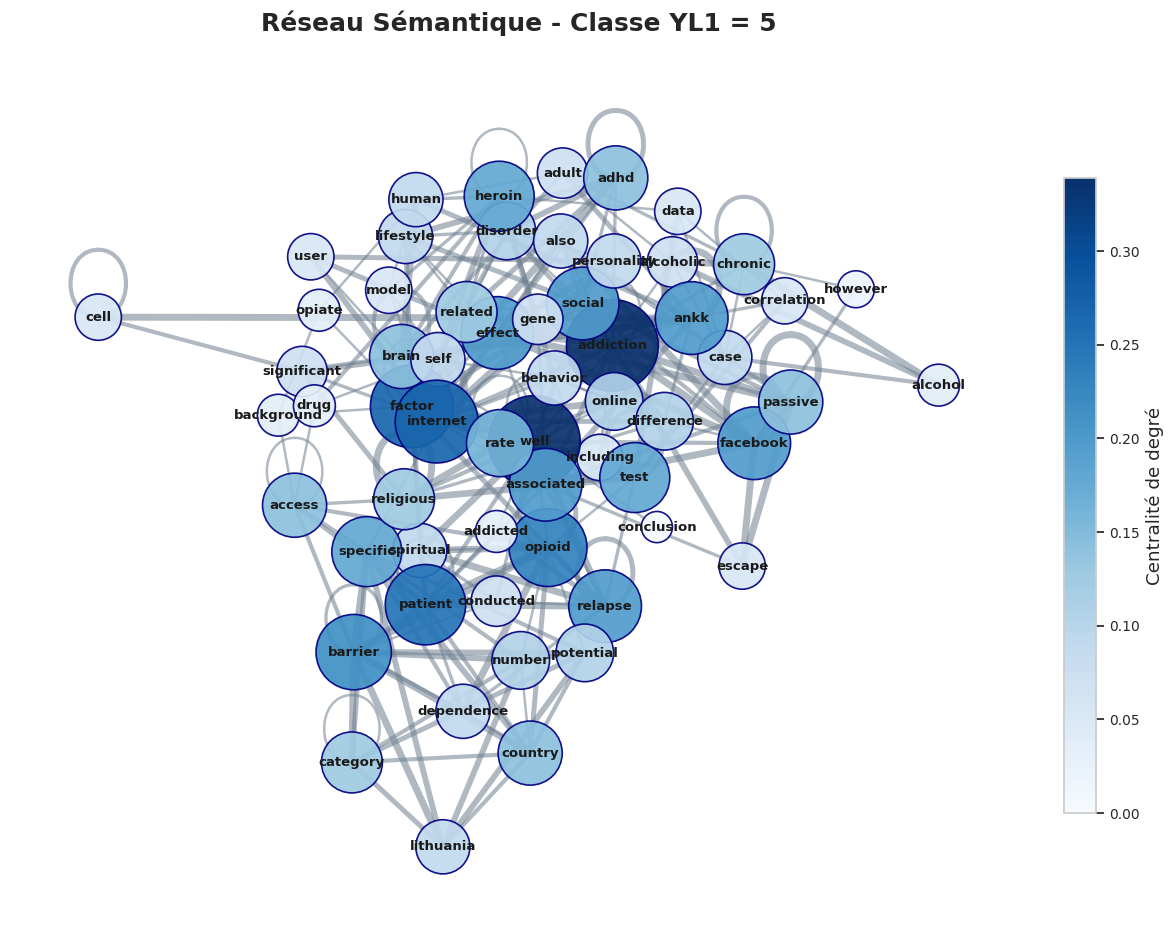

In [ ]:
import os
import networkx as nx
import matplotlib.pyplot as plt
from collections import defaultdict
import nltk
from nltk.stem import WordNetLemmatizer

# Téléchargement silencieux si nécessaire
nltk.download('wordnet', quiet=True)

lemmatizer = WordNetLemmatizer()

def plot_semantic_network(texts, max_words=80, min_edge_weight=2, window_size=5,
                         title="Réseau Sémantique - Concepts Clés", save_path=None):
    """
    Graphe de co-occurrence robuste pour textes scientifiques
    - Fenêtre glissante
    - Lemmatisation
    - Filtre poids minimum
    - Coloration par centralité (degré)
    """
    custom_stopwords = {
        'paper', 'study', 'research', 'result', 'method', 'approach', 'using', 'used',
        'provide', 'provides', 'proposed', 'present', 'based', 'show', 'shown',
        'within', 'between', 'through', 'this', 'these', 'such', 'from', 'with',
        'for', 'the', 'and', 'of', 'in', 'on', 'to', 'a', 'an', 'as'
    }

    # 1. Nettoyage + lemmatisation
    all_tokens = []
    for text in texts:
        tokens = [w.lower() for w in text.split() if len(w) > 3]
        tokens = [lemmatizer.lemmatize(w) for w in tokens if w not in custom_stopwords]
        all_tokens.extend(tokens)

    if len(all_tokens) < 10:
        print("Pas assez de tokens significatifs")
        return

    # Limiter le nombre de tokens aux mots les plus fréquents
    freq = defaultdict(int)
    for t in all_tokens:
        freq[t] += 1
    most_common = sorted(freq.items(), key=lambda x: x[1], reverse=True)[:max_words]
    top_tokens = set([w for w, _ in most_common])
    all_tokens = [t for t in all_tokens if t in top_tokens]

    # 2. Co-occurrence dans une fenêtre glissante
    edges = defaultdict(int)
    for i in range(len(all_tokens)):
        for j in range(i+1, min(i + window_size + 1, len(all_tokens))):
            u, v = sorted([all_tokens[i], all_tokens[j]])  # graphe non orienté
            edges[(u, v)] += 1

    # 3. Filtrer les arêtes trop faibles
    edges = {k: v for k, v in edges.items() if v >= min_edge_weight}
    if not edges:
        print("Aucune arête significative après filtrage")
        return

    # 4. Création du graphe
    G = nx.Graph()
    for (u, v), weight in edges.items():
        G.add_edge(u, v, weight=weight)

    # 5. Layout + design
    fig, ax = plt.subplots(figsize=(16, 11))
    pos = nx.kamada_kawai_layout(G)

    # Centralité pour taille et couleur
    centrality = nx.degree_centrality(G)
    node_sizes = [centrality[n] * 12000 + 300 for n in G.nodes()]
    node_colors = [centrality[n] for n in G.nodes()]

    nx.draw_networkx_nodes(G, pos, ax=ax,
                          node_size=node_sizes,
                          node_color=node_colors,
                          cmap=plt.cm.Blues,
                          alpha=0.92,
                          linewidths=1.2,
                          edgecolors='navy')

    nx.draw_networkx_edges(G, pos, ax=ax,
                          width=[min(G[u][v]['weight']*0.6, 5) for u,v in G.edges()],
                          edge_color="slategray",
                          alpha=0.55)

    nx.draw_networkx_labels(G, pos, ax=ax,
                           font_size=9.5,
                           font_weight="bold",
                           font_family="sans-serif")

    ax.set_title(title, fontsize=18, pad=30, fontweight='bold')
    ax.axis('off')

    # Colorbar
    sm = plt.cm.ScalarMappable(cmap=plt.cm.Blues,
                              norm=plt.Normalize(vmin=0, vmax=max(centrality.values())))
    cbar = plt.colorbar(sm, ax=ax, label="Centralité de degré", shrink=0.75, pad=0.03)
    cbar.ax.tick_params(labelsize=10)

    # Sauvegarde
    if save_path:
        os.makedirs(os.path.dirname(save_path), exist_ok=True)  # crée le dossier si besoin
        plt.savefig(save_path, dpi=400, bbox_inches='tight')
        print(f"Graphe sauvegardé : {save_path}")

    plt.show()


# ─────────────── Exemples d'utilisation ───────────────
# 1. Un seul document
plot_semantic_network([df['texte_clean'].iloc[305]],
                     title="Réseau Sémantique - Exemple Document")

# 2. Classe YL1
classe = 5
texts_classe = df[df['YL1'] == classe]['texte_clean'].tolist()
texts_classe = texts_classe[:10]  # Limite pour test rapide

plot_semantic_network(
    texts_classe,
    max_words=60,
    min_edge_weight=3,
    title=f"Réseau Sémantique - Classe YL1 = {classe}",
    save_path="figures/reseau_classe_YL1_5.png"
)


In [ ]:
import pandas as pd
import ipywidgets as widgets
from IPython.display import display, clear_output

# =================================================================
# 1. NETTOYAGE ET MÉLANGE (CRUCIAL)
# =================================================================

# On mélange tout le dataset aléatoirement pour ne plus avoir les 0 au début
# frac=1 signifie 100% des données, random_state permet de retrouver le même mélange
df = df.sample(frac=1, random_state=42).reset_index(drop=True)

# On s'assure que les colonnes sont bien des entiers pour l'affichage
df['YL1'] = df['YL1'].astype(int)
df['YL2'] = df['YL2'].astype(int)
df['Y'] = df['Y'].astype(int)

# =================================================================
# 2. EXPLORATEUR DYNAMIQUE CORRIGÉ
# =================================================================

def afficher_details_document(index):
    clear_output(wait=True)

    try:
        idx = int(index)
        if idx < 0 or idx >= len(df):
            print(f"❌ Erreur : L'index doit être entre 0 et {len(df)-1}")
            return

        # Extraction sécurisée avec .iloc
        phrase = df.iloc[idx]['texte']
        l1 = df.iloc[idx]['YL1']
        l2 = df.iloc[idx]['YL2']
        y  = df.iloc[idx]['Y']

        print(f"🔍 EXPLORATION DU DOCUMENT INDEX N°{idx} (Après mélange)")
        print("="*65)
        print(f"📝 CONTENU TEXTUEL :")
        print(f"\"{str(phrase)[:500]}...\"")
        print("-" * 65)
        print(f"📍 CHEMIN HIÉRARCHIQUE DANS LE DATASET :")
        print(f"   Niveau Parent (L1)  : {l1}")
        print(f"   Niveau Moyen  (L2)  : {l2}")
        print(f"   Niveau Feuille (Y)  : {y}")
        print("="*65)
        print(f"\n💡 Note : Grâce au mélange, l'index {idx} pointe maintenant")
        print(f"sur une branche réelle du dataset (ici {l1} > {l2} > {y}).")

    except Exception as e:
        print(f"⚠️ Erreur : {e}")

# Création de l'interface
print("Testez différents index (ex: 0, 5, 50, 500) pour voir les branches changer :")
input_text = widgets.IntText(value=0, description='Index :', continuous_update=False)

widgets.interact(afficher_details_document, index=input_text)

Testez différents index (ex: 0, 5, 50, 500) pour voir les branches changer :


interactive(children=(IntText(value=0, description='Index :'), Output()), _dom_classes=('widget-interact',))

<function __main__.afficher_details_document(index)>

In [ ]:
# On se concentre sur 'texte' pour prédire 'YL1'
X = df['texte']
y = df['YL1']

# Division en train (entraînement) et test (évaluation)
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

# Transformation du texte en vecteurs
vectorizer = TfidfVectorizer(max_features=5000, stop_words='english')
X_train_vec = vectorizer.fit_transform(X_train)
X_test_vec = vectorizer.transform(X_test)

print(f"Données vectorisées. Taille du vocabulaire : {len(vectorizer.get_feature_names_out())}")

Données vectorisées. Taille du vocabulaire : 5000


In [ ]:
# Création et entraînement du modèle
model = LogisticRegression(max_iter=1000)
model.fit(X_train_vec, y_train)

print("Modèle entraîné avec succès sur YL1.")

Modèle entraîné avec succès sur YL1.


In [ ]:
# Prédictions
y_pred = model.predict(X_test_vec)

# Affichage des résultats
print("--- Rapport de Classification ---")
print(classification_report(y_test, y_pred))
print(f"Précision globale (Accuracy) : {accuracy_score(y_test, y_pred):.2%}")


--- Rapport de Classification ---
              precision    recall  f1-score   support

           0       0.87      0.87      0.87       315
           1       0.96      0.87      0.91       230
           2       0.92      0.97      0.94       383
           3       0.89      0.91      0.90       383
           4       0.89      0.92      0.91       423
           5       0.87      0.84      0.86       296
           6       0.91      0.90      0.90       353

    accuracy                           0.90      2383
   macro avg       0.90      0.90      0.90      2383
weighted avg       0.90      0.90      0.90      2383

Précision globale (Accuracy) : 90.10%


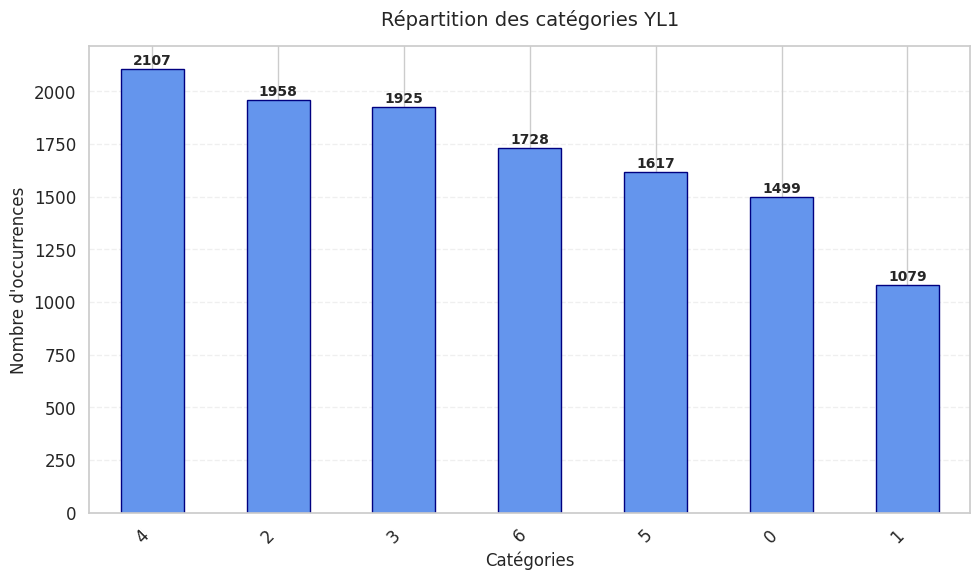

In [ ]:
import matplotlib.pyplot as plt

# Définir une palette de couleurs spécifique pour toutes les catégories
# Ici je prends 10 couleurs mais tu peux en adapter selon le nombre exact de catégories
colors = ['#6495ED']
# ---- Graphique pour YL1 ----
plt.figure(figsize=(10, 6))

# On récupère les counts et les index
counts_YL1 = df['YL1'].value_counts()
categories_YL1 = counts_YL1.index

# On assigne une couleur par catégorie (limitées aux 7 existantes)
colors_YL1 = colors[:len(categories_YL1)]

counts_YL1.plot(kind='bar',
                color=colors_YL1,
                edgecolor='navy')

plt.title('Répartition des catégories YL1', fontsize=14, pad=15)
plt.xlabel('Catégories', fontsize=12)
plt.ylabel('Nombre d\'occurrences', fontsize=12)
plt.xticks(rotation=45, ha='right')
plt.grid(axis='y', linestyle='--', alpha=0.3)

# Valeurs au-dessus des barres
for i, v in enumerate(counts_YL1):
    plt.text(i, v + max(counts_YL1)*0.01,
             str(v), ha='center', fontsize=10, fontweight='bold')

plt.tight_layout()
plt.show()

In [ ]:
# 1. On change la cible pour YL2
y_level2 = df['YL2']

# 2. Division des données (on garde le même X)
X_train_2, X_test_2, y_train_2, y_test_2 = train_test_split(
    df['texte'], y_level2, test_size=0.2, random_state=42
)

# 3. Vectorisation
X_train_vec_2 = vectorizer.fit_transform(X_train_2)
X_test_vec_2 = vectorizer.transform(X_test_2)

# 4. Entraînement du modèle pour le Niveau 2
model_yl2 = LogisticRegression(max_iter=1000)
model_yl2.fit(X_train_vec_2, y_train_2)

# 5. Évaluation
y_pred_2 = model_yl2.predict(X_test_vec_2)
print("--- Rapport de Classification pour YL2 (Sous-catégories) ---")
print(classification_report(y_test_2, y_pred_2))
print(f"Précision globale (Accuracy) : {accuracy_score(y_test_2, y_pred_2):.2%}")

--- Rapport de Classification pour YL2 (Sous-catégories) ---
              precision    recall  f1-score   support

           0       0.80      0.82      0.81       507
           1       0.75      0.79      0.77       415
           2       0.83      0.83      0.83       545
           3       0.87      0.79      0.83       402
           4       0.82      0.82      0.82       514

    accuracy                           0.81      2383
   macro avg       0.81      0.81      0.81      2383
weighted avg       0.81      0.81      0.81      2383

Précision globale (Accuracy) : 81.24%


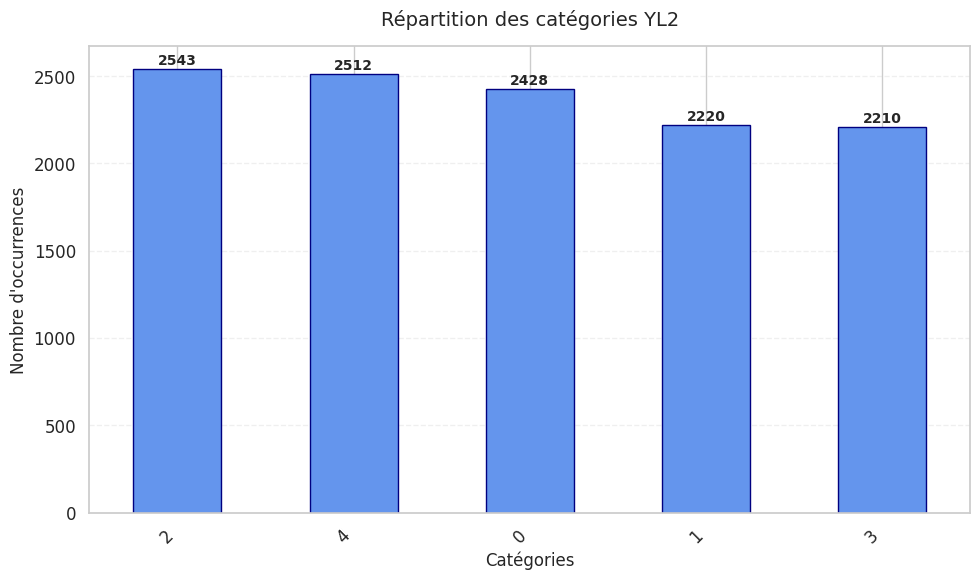

In [ ]:
# ---- Graphique pour YL2 ----
plt.figure(figsize=(10, 6))

counts_YL2 = df['YL2'].value_counts()
categories_YL2 = counts_YL2.index
colors_YL2 = colors[:len(categories_YL2)]  # 5 couleurs pour 5 catégories

counts_YL2.plot(kind='bar',
                color=colors_YL2,
                edgecolor='navy')

plt.title('Répartition des catégories YL2', fontsize=14, pad=15)
plt.xlabel('Catégories', fontsize=12)
plt.ylabel('Nombre d\'occurrences', fontsize=12)
plt.xticks(rotation=45, ha='right')
plt.grid(axis='y', linestyle='--', alpha=0.3)

for i, v in enumerate(counts_YL2):
    plt.text(i, v + max(counts_YL2)*0.01,
             str(v), ha='center', fontsize=10, fontweight='bold')

plt.tight_layout()
plt.show()

In [ ]:
# ==============================================
# BASELINE PLATE SUR LE NIVEAU LEAF (Y) - 33 classes
# ==============================================

from sklearn.linear_model import LogisticRegression
from sklearn.metrics import classification_report, accuracy_score
from sklearn.model_selection import train_test_split
from sklearn.feature_extraction.text import TfidfVectorizer

# On refait un split DÉDIÉ pour le niveau Y (cohérent avec les précédents)
# On stratifie sur YL1 pour garder la même répartition des domaines que pour YL1/YL2
X_train_y, X_test_y, y_train_y, y_test_y = train_test_split(
    df['texte_clean'],           # ou df['texte'] si tu préfères ne pas utiliser le clean
    df['Y'],                     # la colonne cible : les 33 spécialités (feuilles)
    test_size=0.2,
    random_state=42,
    stratify=df['YL1']           # très important pour cohérence avec tes splits précédents
)

# Vectorisation spécifique pour cette baseline (recommandé)
vectorizer_y = TfidfVectorizer(max_features=5000, stop_words='english')
X_train_vec_y = vectorizer_y.fit_transform(X_train_y)
X_test_vec_y  = vectorizer_y.transform(X_test_y)

# Modèle baseline plate sur Y
model_y_flat = LogisticRegression(max_iter=1000, random_state=42)
model_y_flat.fit(X_train_vec_y, y_train_y)

# Prédictions et évaluation
y_pred_y_flat = model_y_flat.predict(X_test_vec_y)

print("\n" + "="*60)
print("BASELINE PLATE : Prédiction DIRECTE sur le niveau LEAF (Y - 33 classes)")
print("="*60 + "\n")

print(classification_report(y_test_y, y_pred_y_flat))
acc_y_flat = accuracy_score(y_test_y, y_pred_y_flat)
print(f"Accuracy globale sur le niveau LEAF (Y) : {acc_y_flat:.2%}")


BASELINE PLATE : Prédiction DIRECTE sur le niveau LEAF (Y - 33 classes)

              precision    recall  f1-score   support

           0       0.81      0.75      0.78        57
           1       0.85      0.65      0.74        54
           2       0.79      0.88      0.83        60
           3       0.91      0.88      0.89        67
           4       0.92      0.79      0.85        62
           5       0.86      0.86      0.86        59
           6       0.91      0.82      0.86        72
           7       0.85      0.95      0.90        85
           8       0.73      0.84      0.78        77
           9       0.71      0.72      0.72        82
          10       0.69      0.72      0.70        81
          11       0.88      0.79      0.83        76
          12       0.76      0.82      0.78        76
          13       0.80      0.78      0.79        68
          14       0.85      0.81      0.83        79
          15       0.74      0.89      0.81        64
       

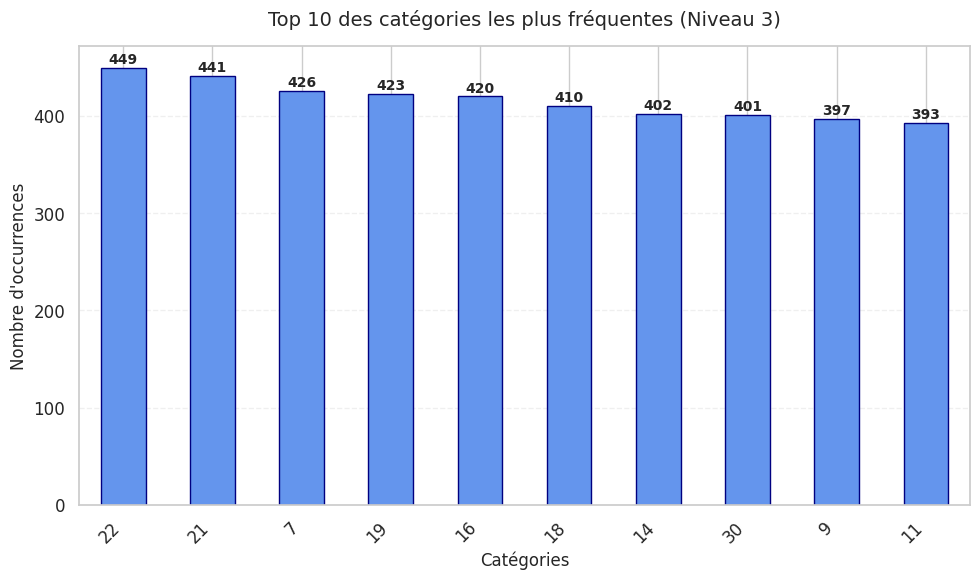

In [ ]:
import matplotlib.pyplot as plt

plt.figure(figsize=(10, 6))  # taille du graphique

df['Y'].value_counts().head(10).plot(kind='bar',
                                    color='cornflowerblue',
                                    edgecolor='navy')

plt.title('Top 10 des catégories les plus fréquentes (Niveau 3)', fontsize=14, pad=15)
plt.xlabel('Catégories', fontsize=12)
plt.ylabel('Nombre d\'occurrences', fontsize=12)
plt.xticks(rotation=45, ha='right')   # rotation des étiquettes pour mieux lire
plt.grid(axis='y', linestyle='--', alpha=0.3)

# Ajout des valeurs au-dessus des barres (optionnel mais très apprécié)
for i, v in enumerate(df['Y'].value_counts().head(10)):
    plt.text(i, v + max(df['Y'].value_counts().head(10))*0.01,
             str(v), ha='center', fontsize=10, fontweight='bold')

plt.tight_layout()  # évite que les labels soient coupés
plt.show()

/tmp/ipython-input-1494331777.py:26: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  ax = sns.barplot(x=top_n.index, y=top_n.values, palette="Blues_d", edgecolor="navy", linewidth=1.2)


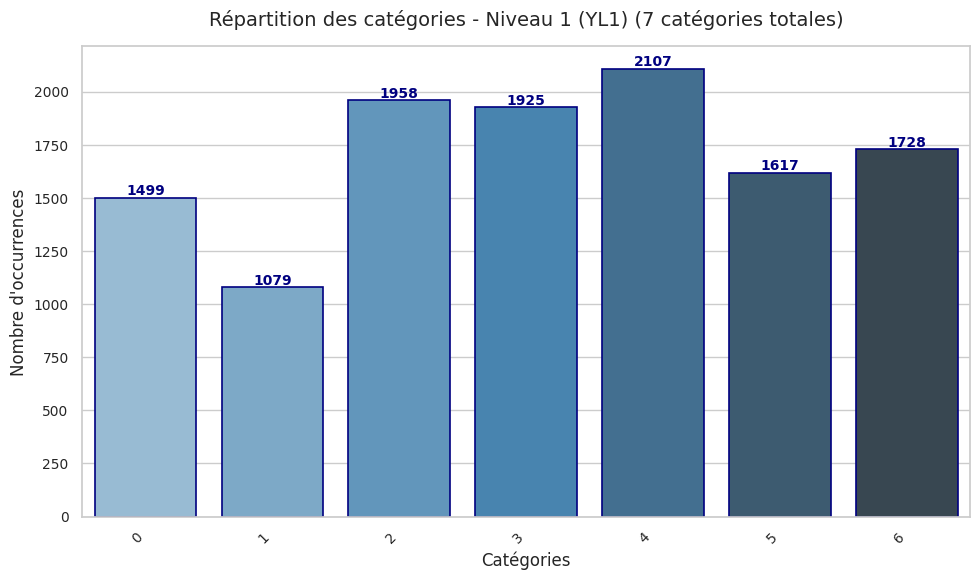

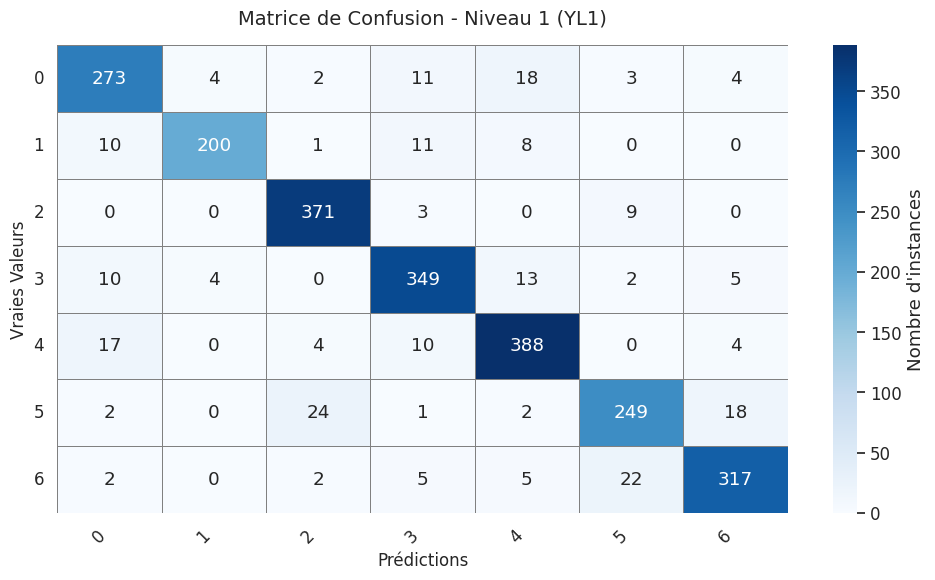

<Figure size 1200x600 with 0 Axes>

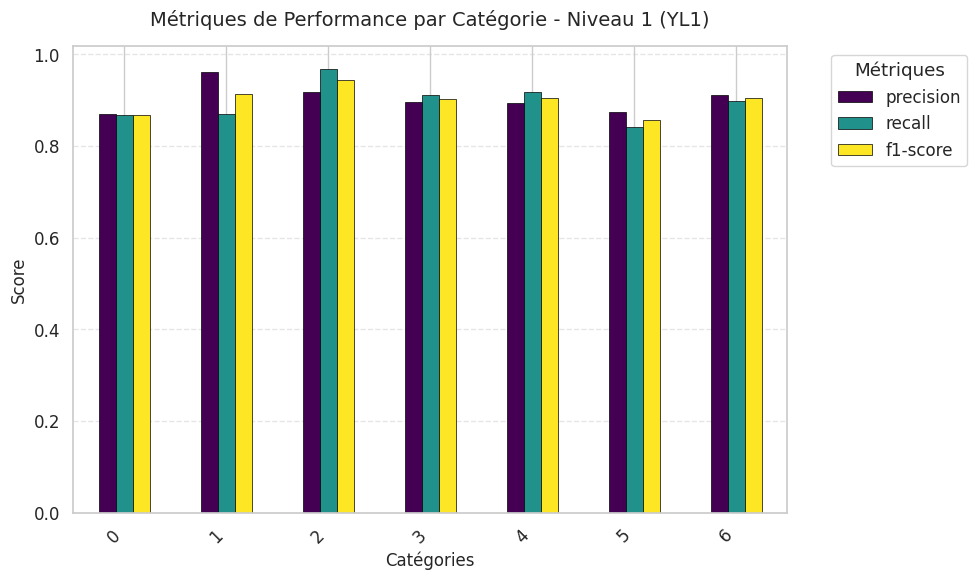

--- Rapport pour Niveau 1 (YL1) ---
              precision    recall  f1-score   support

           0       0.87      0.87      0.87       315
           1       0.96      0.87      0.91       230
           2       0.92      0.97      0.94       383
           3       0.89      0.91      0.90       383
           4       0.89      0.92      0.91       423
           5       0.87      0.84      0.86       296
           6       0.91      0.90      0.90       353

    accuracy                           0.90      2383
   macro avg       0.90      0.90      0.90      2383
weighted avg       0.90      0.90      0.90      2383

Précision globale : 90.10%


In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns
import pandas as pd
from sklearn.metrics import confusion_matrix, classification_report, accuracy_score

# Style global pour des graphiques académiques (élégant et lisible)
sns.set(style="whitegrid", palette="muted", font_scale=1.1, rc={"figure.figsize": (10, 6)})
plt.rcParams['font.family'] = 'sans-serif'  # Police professionnelle
plt.rcParams['savefig.dpi'] = 300  # Haute résolution pour mémoire

def generate_plots_for_level(df, column, level_name, max_bars=10, save_path="graphs/"):
    """
    Génère des graphiques jolis pour un niveau (ex: YL1, YL2, Y).
    - Répartition des catégories
    - Matrice de confusion (heatmap)
    - Barres pour métriques (precision, recall, f1)
    Exporte en PNG et PDF pour ton mémoire.
    """
    # 1. Répartition des catégories (amélioré)
    counts = df[column].value_counts()
    n_categories = len(counts)
    n_to_show = min(max_bars, n_categories)
    top_n = counts.head(n_to_show)

    plt.figure()
    ax = sns.barplot(x=top_n.index, y=top_n.values, palette="Blues_d", edgecolor="navy", linewidth=1.2)
    plt.title(f"Répartition des catégories - {level_name} ({n_categories} catégories totales)", fontsize=14, pad=15)
    plt.xlabel("Catégories", fontsize=12)
    plt.ylabel("Nombre d'occurrences", fontsize=12)
    plt.xticks(rotation=45, ha='right', fontsize=10)
    plt.yticks(fontsize=10)

    # Ajout des valeurs au-dessus des barres
    for p in ax.patches:
        ax.annotate(f'{int(p.get_height())}',
                    (p.get_x() + p.get_width() / 2., p.get_height()),
                    ha='center', va='bottom', fontsize=10, fontweight='bold', color='navy')

    plt.tight_layout()
    plt.savefig(f"{save_path}repartition_{level_name}.png")
    plt.savefig(f"{save_path}repartition_{level_name}.pdf")
    plt.show()

    # 2. Prédictions et métriques (basé sur ton code 2)
    # (Adapte avec tes variables réelles : model, X_test_vec, y_test)
    y_pred = model.predict(X_test_vec)  # Remplace par ton model.predict pour ce niveau

    # Heatmap de la matrice de confusion
    cm = confusion_matrix(y_test, y_pred)
    labels = sorted(df[column].unique())  # Labels des catégories

    plt.figure()
    sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', xticklabels=labels, yticklabels=labels,
                linewidths=0.5, linecolor='gray', cbar_kws={'label': 'Nombre d\'instances'})
    plt.title(f"Matrice de Confusion - {level_name}", fontsize=14, pad=15)
    plt.xlabel("Prédictions", fontsize=12)
    plt.ylabel("Vraies Valeurs", fontsize=12)
    plt.xticks(rotation=45, ha='right')
    plt.yticks(rotation=0)
    plt.tight_layout()
    plt.savefig(f"{save_path}confusion_matrix_{level_name}.png")
    plt.savefig(f"{save_path}confusion_matrix_{level_name}.pdf")
    plt.show()

    # 3. Barres pour métriques (precision, recall, f1-score)
    report = classification_report(y_test, y_pred, output_dict=True)
    metrics_df = pd.DataFrame(report).transpose().drop(['support'], axis=1).drop(['accuracy', 'macro avg', 'weighted avg'])

    plt.figure(figsize=(12, 6))
    metrics_df.plot(kind='bar', colormap='viridis', edgecolor='black', linewidth=0.5)
    plt.title(f"Métriques de Performance par Catégorie - {level_name}", fontsize=14, pad=15)
    plt.xlabel("Catégories", fontsize=12)
    plt.ylabel("Score", fontsize=12)
    plt.xticks(rotation=45, ha='right')
    plt.legend(title="Métriques", bbox_to_anchor=(1.05, 1), loc='upper left')
    plt.grid(axis='y', linestyle='--', alpha=0.5)
    plt.tight_layout()
    plt.savefig(f"{save_path}metrics_{level_name}.png")
    plt.savefig(f"{save_path}metrics_{level_name}.pdf")
    plt.show()

    # Affichage du rapport textuel (pour vérif)
    print(f"--- Rapport pour {level_name} ---")
    print(classification_report(y_test, y_pred))
    print(f"Précision globale : {accuracy_score(y_test, y_pred):.2%}")


# ─────────────── Utilisation ───────────────────
# Crée un dossier 'graphs' pour les exports si besoin
import os
os.makedirs("graphs", exist_ok=True)

# Pour YL1 (7 catégories) - Adapte tes variables (X_train_vec, etc.) pour chaque niveau
# (Ton code 1 est déjà bon ; réutilise-le avant d'appeler la fonction)
generate_plots_for_level(df, 'YL1', "Niveau 1 (YL1)", max_bars=10, save_path="graphs/")


# Pour Y (top 10) - Même chose
#generate_plots_for_level(df, 'Y', "Niveau 3 (Y)", max_bars=10, save_path="graphs/")

/tmp/ipython-input-3551278823.py:28: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  ax = sns.barplot(x=counts.index, y=counts.values,


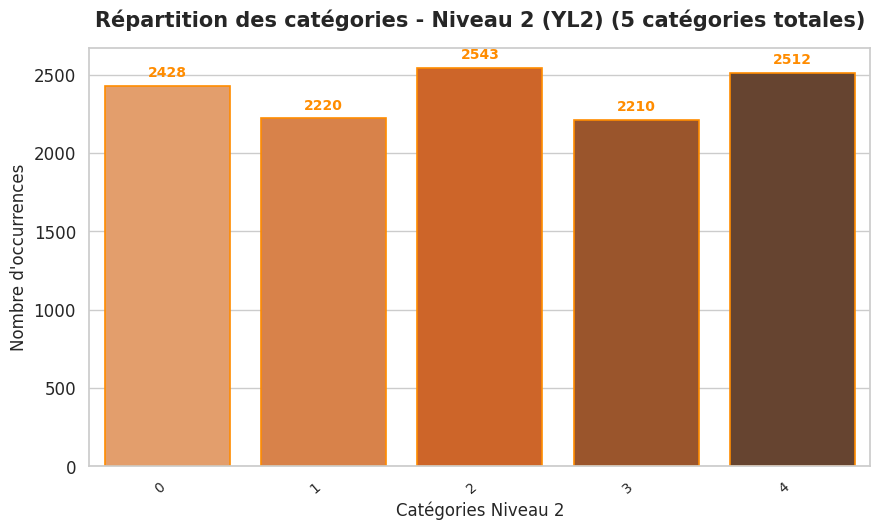

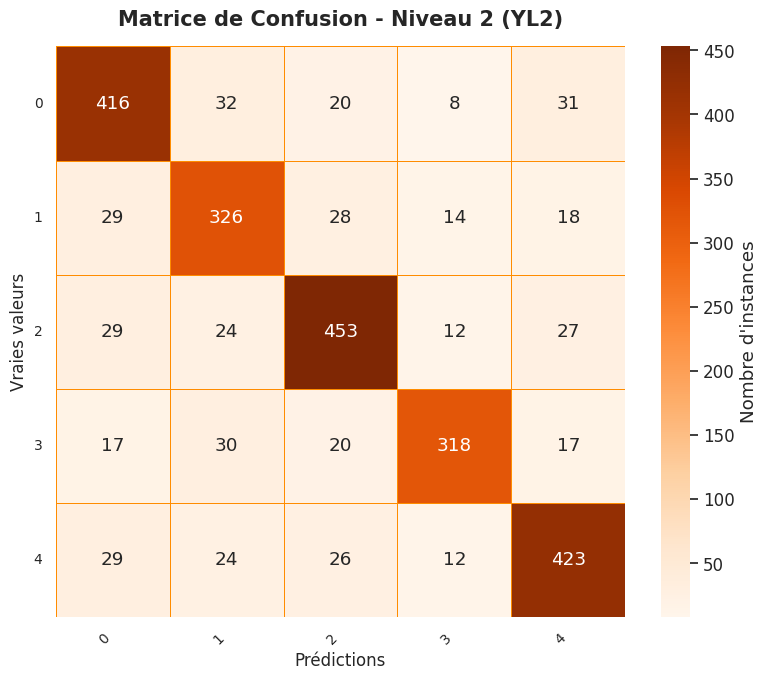

<Figure size 1000x600 with 0 Axes>

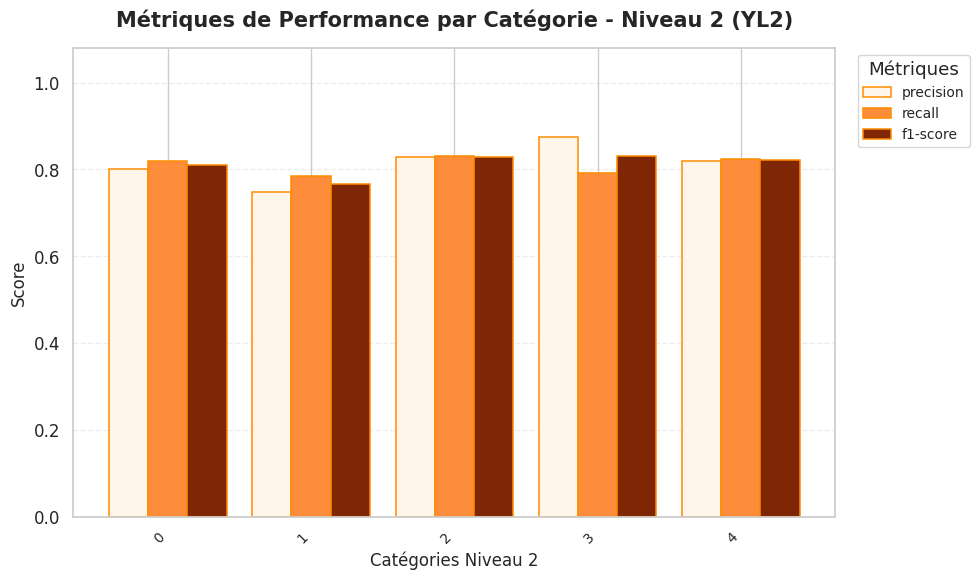


=== Rapport de performance - Niveau 2 (YL2) ===

              precision    recall  f1-score   support

           0       0.80      0.82      0.81       507
           1       0.75      0.79      0.77       415
           2       0.83      0.83      0.83       545
           3       0.87      0.79      0.83       402
           4       0.82      0.82      0.82       514

    accuracy                           0.81      2383
   macro avg       0.81      0.81      0.81      2383
weighted avg       0.81      0.81      0.81      2383

Précision globale (Accuracy) : 81.24%


In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns
import pandas as pd
from sklearn.metrics import confusion_matrix, classification_report, accuracy_score
import os

# Style global (cohérent avec tes autres graphiques)
sns.set(style="whitegrid", palette="muted", font_scale=1.1)
plt.rcParams['font.family'] = 'sans-serif'
plt.rcParams['savefig.dpi'] = 300

def generate_plots_for_level_yl2(save_path="graphs/"):
    """
    Génère les 3 graphiques pour le niveau YL2 uniquement
    Utilise directement y_test_2 et y_pred_2
    Palette orange pour différencier du niveau 1 (bleu/vert)
    """
    level_name = "Niveau 2 (YL2)"
    column = 'YL2'  # pour les labels et la répartition

    os.makedirs(save_path, exist_ok=True)

    # 1. Répartition des catégories (sur l'ensemble du dataset)
    plt.figure(figsize=(9, 5.5))
    counts = df[column].value_counts()
    n_categories = len(counts)

    ax = sns.barplot(x=counts.index, y=counts.values,
                     palette="Oranges_d", edgecolor="darkorange", linewidth=1.2)

    plt.title(f"Répartition des catégories - {level_name} ({n_categories} catégories totales)",
              fontsize=15, pad=15, fontweight='bold')
    plt.xlabel("Catégories Niveau 2", fontsize=12)
    plt.ylabel("Nombre d'occurrences", fontsize=12)
    plt.xticks(rotation=40, ha='right', fontsize=10)

    for p in ax.patches:
        ax.annotate(f'{int(p.get_height())}',
                    (p.get_x() + p.get_width()/2., p.get_height() + max(counts)*0.015),
                    ha='center', va='bottom', fontsize=10,
                    color='darkorange', fontweight='bold')

    plt.tight_layout()
    plt.savefig(f"{save_path}repartition_{level_name}.png", bbox_inches='tight')
    plt.savefig(f"{save_path}repartition_{level_name}.pdf", bbox_inches='tight')
    plt.show()

    # 2. Matrice de confusion
    cm = confusion_matrix(y_test_2, y_pred_2)
    labels = sorted(df[column].unique())

    plt.figure(figsize=(8, 7))
    sns.heatmap(cm, annot=True, fmt='d', cmap='Oranges',
                xticklabels=labels, yticklabels=labels,
                linewidths=0.6, linecolor='darkorange',
                cbar_kws={'label': "Nombre d'instances"})

    plt.title(f"Matrice de Confusion - {level_name}", fontsize=15, pad=15, fontweight='bold')
    plt.xlabel("Prédictions", fontsize=12)
    plt.ylabel("Vraies valeurs", fontsize=12)
    plt.xticks(rotation=45, ha='right', fontsize=10)
    plt.yticks(rotation=0, fontsize=10)
    plt.tight_layout()
    plt.savefig(f"{save_path}confusion_matrix_{level_name}.png", bbox_inches='tight')
    plt.savefig(f"{save_path}confusion_matrix_{level_name}.pdf", bbox_inches='tight')
    plt.show()

    # 3. Métriques par classe (Precision / Recall / F1-score)
    report = classification_report(y_test_2, y_pred_2, output_dict=True, zero_division=0)
    metrics_df = pd.DataFrame(report).transpose()
    metrics_df = metrics_df.drop(['accuracy', 'macro avg', 'weighted avg'], errors='ignore')
    metrics_df = metrics_df[['precision', 'recall', 'f1-score']]

    plt.figure(figsize=(10, 6))
    metrics_df.plot(kind='bar',
                    colormap='Oranges',
                    edgecolor='darkorange',
                    linewidth=1.1,
                    width=0.82)

    plt.title(f"Métriques de Performance par Catégorie - {level_name}",
              fontsize=15, pad=15, fontweight='bold')
    plt.xlabel("Catégories Niveau 2", fontsize=12)
    plt.ylabel("Score", fontsize=12)
    plt.xticks(rotation=45, ha='right', fontsize=10)
    plt.ylim(0, 1.08)

    plt.legend(title="Métriques",
               bbox_to_anchor=(1.02, 1),
               loc='upper left',
               fontsize=10)

    plt.grid(axis='y', linestyle='--', alpha=0.35)
    plt.tight_layout()
    plt.savefig(f"{save_path}metrics_{level_name}.png", bbox_inches='tight')
    plt.savefig(f"{save_path}metrics_{level_name}.pdf", bbox_inches='tight')
    plt.show()

    # Rapport textuel pour vérification
    print(f"\n=== Rapport de performance - {level_name} ===\n")
    print(classification_report(y_test_2, y_pred_2, zero_division=0))
    print(f"Précision globale (Accuracy) : {accuracy_score(y_test_2, y_pred_2):.2%}")


# ─────────────── Utilisation ───────────────
generate_plots_for_level_yl2(save_path="graphs/")

/tmp/ipython-input-782324355.py:28: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  ax = sns.barplot(x=top_classes.index.astype(str),


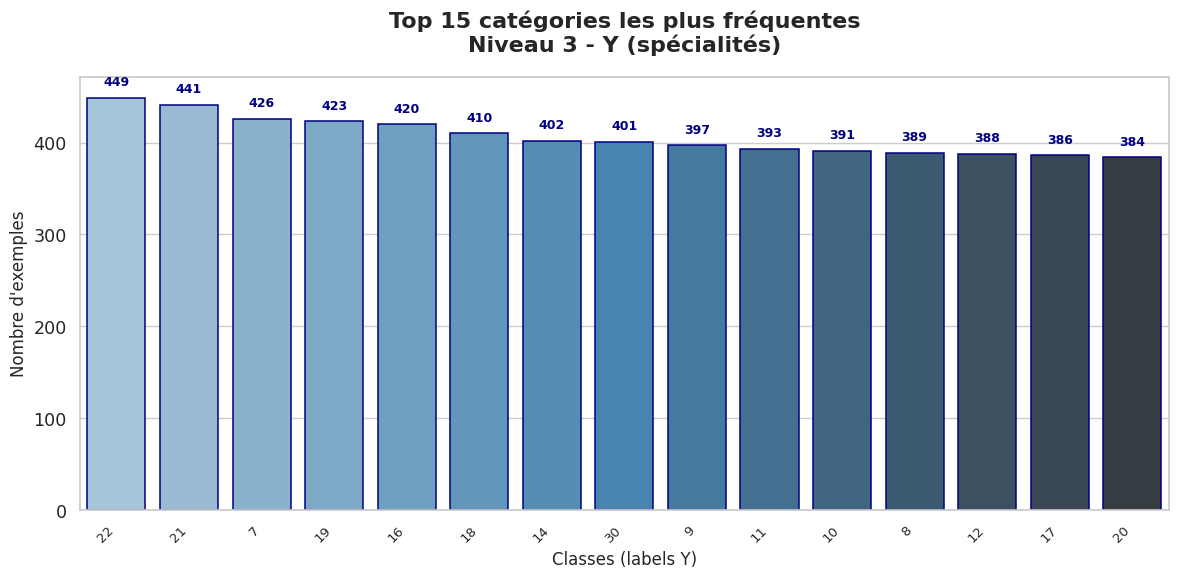

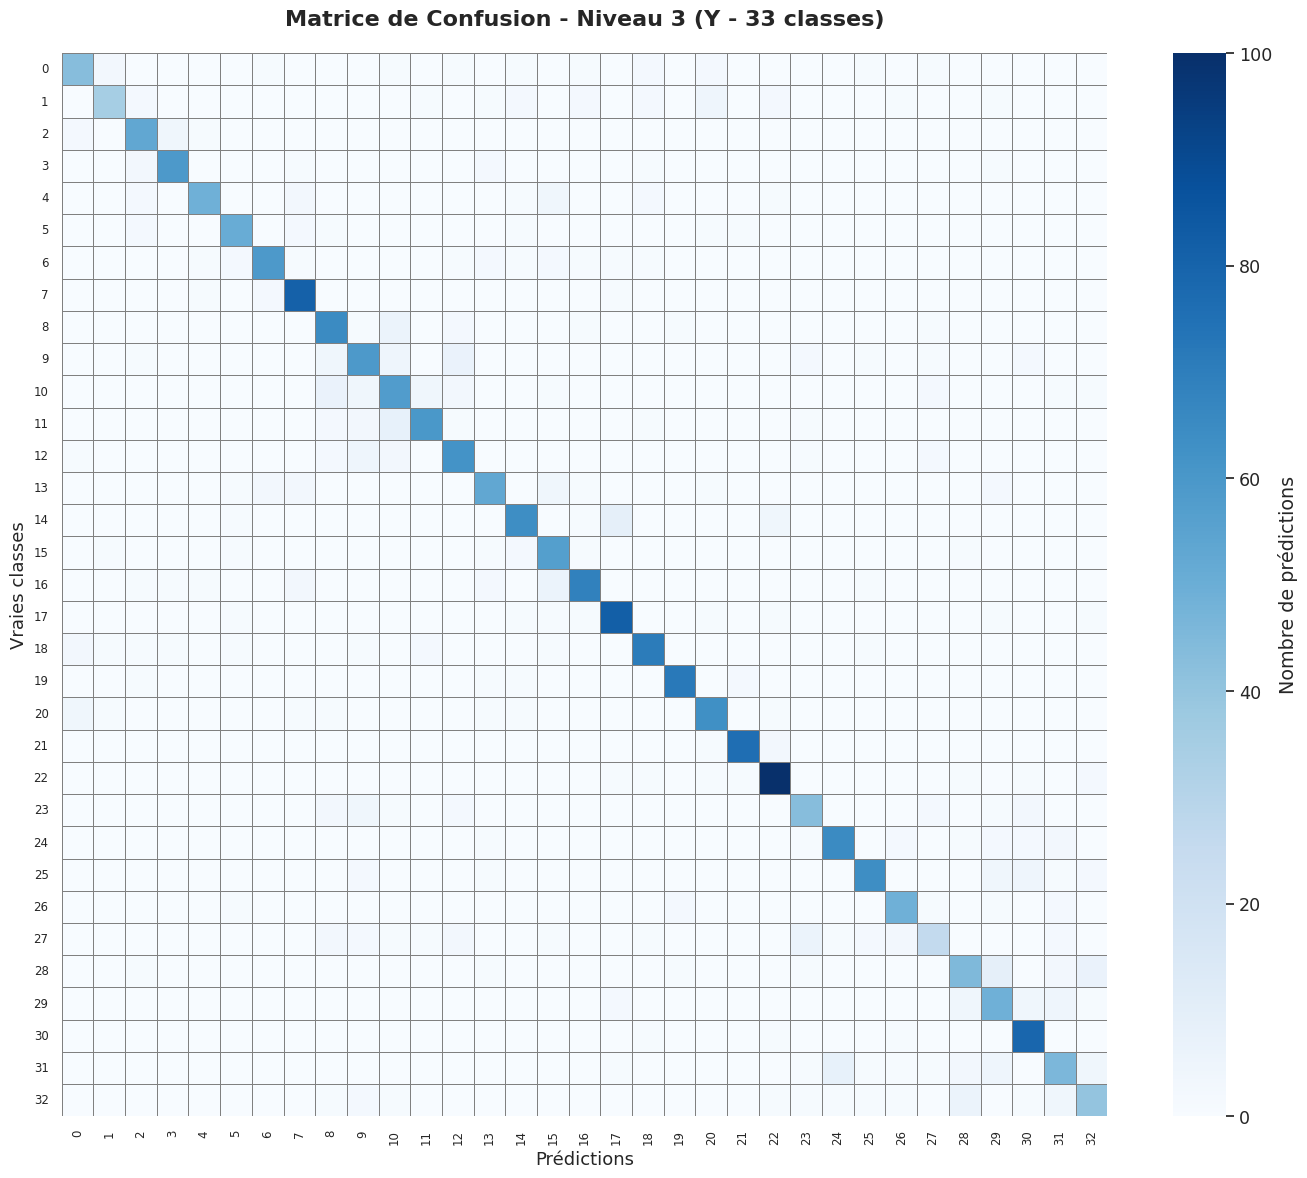

<Figure size 1400x700 with 0 Axes>

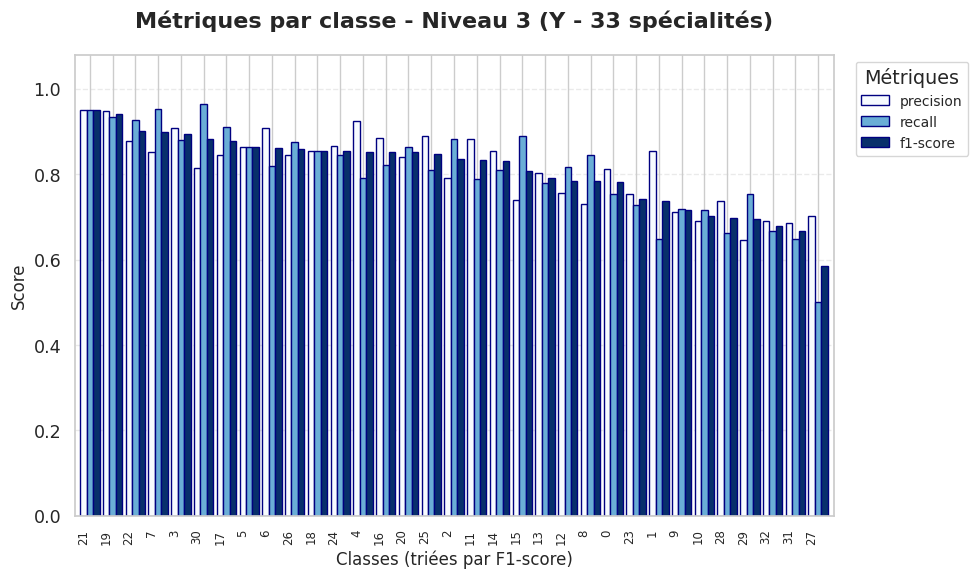


══════════════════════════════════════════════════════════════════════
RAPPORT DÉTAILLÉ - Niveau Y (33 classes)
══════════════════════════════════════════════════════════════════════

              precision    recall  f1-score   support

           0       0.81      0.75      0.78        57
           1       0.85      0.65      0.74        54
           2       0.79      0.88      0.83        60
           3       0.91      0.88      0.89        67
           4       0.92      0.79      0.85        62
           5       0.86      0.86      0.86        59
           6       0.91      0.82      0.86        72
           7       0.85      0.95      0.90        85
           8       0.73      0.84      0.78        77
           9       0.71      0.72      0.72        82
          10       0.69      0.72      0.70        81
          11       0.88      0.79      0.83        76
          12       0.76      0.82      0.78        76
          13       0.80      0.78      0.79        68
    

In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns
import pandas as pd
from sklearn.metrics import confusion_matrix, classification_report, accuracy_score
import os

# Style global cohérent
sns.set(style="whitegrid", font_scale=1.15)
plt.rcParams['savefig.dpi'] = 300
plt.rcParams['font.family'] = 'sans-serif'

# ────────────────────────────────────────────────────────────────
# Fonction spécifique pour le niveau Y (bleu foncé dominant)
# ────────────────────────────────────────────────────────────────

def plot_level_y_performance(save_path="graphs/"):
    """
    Génère 3 graphiques très soignés pour le niveau Y (33 classes)
    Palette : Blues / navy
    """
    level_name = "Niveau 3 - Y (33 classes - baseline plate)"
    os.makedirs(save_path, exist_ok=True)

    # 1. Répartition des catégories (Top 15 au lieu de 10 car 33 classes)
    plt.figure(figsize=(12, 6))
    top_classes = df['Y'].value_counts().head(15)  # Top 15 pour plus de lisibilité

    ax = sns.barplot(x=top_classes.index.astype(str),
                     y=top_classes.values,
                     palette="Blues_d",
                     edgecolor="navy",
                     linewidth=1.1)

    plt.title("Top 15 catégories les plus fréquentes\nNiveau 3 - Y (spécialités)",
              fontsize=16, pad=18, fontweight='bold')
    plt.xlabel("Classes (labels Y)", fontsize=12)
    plt.ylabel("Nombre d'exemples", fontsize=12)
    plt.xticks(rotation=45, ha='right', fontsize=9.5)

    # Annotations sur les barres
    for p in ax.patches:
        ax.annotate(f'{int(p.get_height())}',
                    (p.get_x() + p.get_width()/2., p.get_height() + 10),
                    ha='center', va='bottom', fontsize=9,
                    color='navy', fontweight='bold')

    plt.tight_layout()
    plt.savefig(f"{save_path}repartition_Y_top15.png", bbox_inches='tight')
    plt.show()

    # 2. Matrice de confusion (attention : 33×33 → peut être dense)
    cm = confusion_matrix(y_test_y, y_pred_y_flat)
    labels = sorted(df['Y'].unique())

    plt.figure(figsize=(14, 12))  # plus grand car 33 classes
    sns.heatmap(cm, annot=False, fmt='d', cmap='Blues',
                xticklabels=labels, yticklabels=labels,
                linewidths=0.4, linecolor='gray',
                cbar_kws={'label': "Nombre de prédictions"})

    plt.title("Matrice de Confusion - Niveau 3 (Y - 33 classes)",
              fontsize=16, pad=20, fontweight='bold')
    plt.xlabel("Prédictions", fontsize=13)
    plt.ylabel("Vraies classes", fontsize=13)
    plt.xticks(rotation=90, fontsize=8.5)
    plt.yticks(rotation=0, fontsize=8.5)
    plt.tight_layout()
    plt.savefig(f"{save_path}confusion_matrix_Y.png", bbox_inches='tight')
    plt.show()

    # 3. Métriques par classe (Precision / Recall / F1)
    report = classification_report(y_test_y, y_pred_y_flat, output_dict=True, zero_division=0)
    metrics_df = pd.DataFrame(report).transpose()
    metrics_df = metrics_df.drop(['accuracy', 'macro avg', 'weighted avg'], errors='ignore')
    metrics_df = metrics_df[['precision', 'recall', 'f1-score']]

    # On trie par F1-score pour plus de lisibilité
    metrics_df = metrics_df.sort_values('f1-score', ascending=False)

    plt.figure(figsize=(14, 7))
    metrics_df.plot(kind='bar',
                    colormap='Blues',
                    edgecolor='navy',
                    linewidth=1.0,
                    width=0.85)

    plt.title("Métriques par classe - Niveau 3 (Y - 33 spécialités)",
              fontsize=16, pad=20, fontweight='bold')
    plt.xlabel("Classes (triées par F1-score)", fontsize=12)
    plt.ylabel("Score", fontsize=12)
    plt.xticks(rotation=90, ha='right', fontsize=8.5)
    plt.ylim(0, 1.08)

    plt.legend(title="Métriques",
               bbox_to_anchor=(1.02, 1),
               loc='upper left',
               fontsize=10)

    plt.grid(axis='y', linestyle='--', alpha=0.4)
    plt.tight_layout()
    plt.savefig(f"{save_path}metrics_Y_sorted.png", bbox_inches='tight')
    plt.show()

    # Rapport textuel
    print("\n" + "═"*70)
    print("RAPPORT DÉTAILLÉ - Niveau Y (33 classes)")
    print("═"*70 + "\n")
    print(classification_report(y_test_y, y_pred_y_flat, zero_division=0))
    print(f"Accuracy globale : {accuracy_score(y_test_y, y_pred_y_flat):.2%}")


# ─────────────── Exécution ───────────────
plot_level_y_performance(save_path="graphs/")

📊 ANALYSE STATISTIQUE DE LA HIÉRARCHIE
----------------------------------------
✅ Niveau L1 (Domaines globaux) : 7 catégories uniques
✅ Niveau L2 (Sous-domaines) : 5 catégories uniques
✅ Niveau Y  (Spécialités finales) : 33 catégories uniques


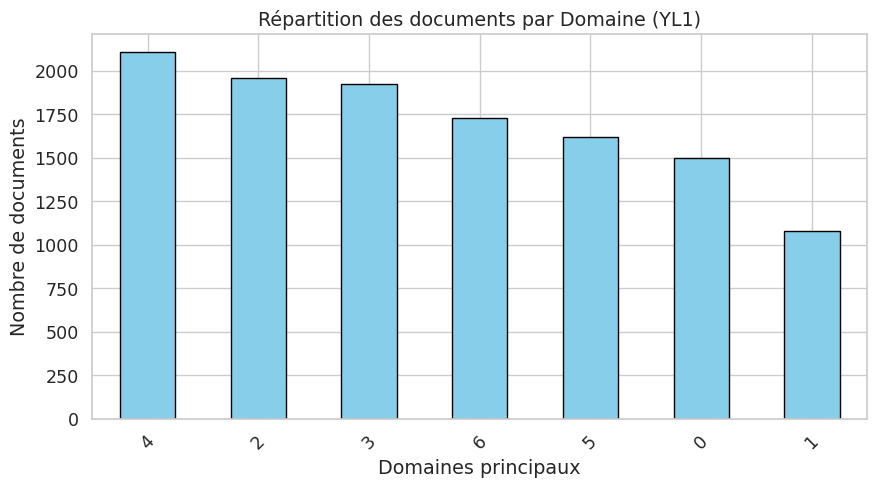


🔍 EXEMPLE DE CHEMIN DANS LE DATASET :
Domaine (L1)     : 6
Sous-Domaine (L2): 2
Spécialité (Y)   : 30


In [ ]:
# =================================================================
# ÉTAPE : ANALYSE DE LA COMPLEXITÉ ET DE LA HIÉRARCHIE
# =================================================================

print("📊 ANALYSE STATISTIQUE DE LA HIÉRARCHIE")
print("-" * 40)

# 1. Calcul des statistiques par niveau
stats = {
    "Niveau L1 (Domaines globaux)": df['YL1'].nunique(),
    "Niveau L2 (Sous-domaines)": df['YL2'].nunique(),
    "Niveau Y  (Spécialités finales)": df['Y'].nunique()
}

for niveau, total in stats.items():
    print(f"✅ {niveau} : {total} catégories uniques")

# 2. Visualisation de la répartition du Niveau 1 (YL1)
import matplotlib.pyplot as plt
import seaborn as sns

plt.figure(figsize=(10, 5))
df['YL1'].value_counts().plot(kind='bar', color='skyblue', edgecolor='black')
plt.title("Répartition des documents par Domaine (YL1)")
plt.xlabel("Domaines principaux")
plt.ylabel("Nombre de documents")
plt.xticks(rotation=45)
plt.show()

# 3. Exemple concret de "Chemin Hiérarchique"
print("\n🔍 EXEMPLE DE CHEMIN DANS LE DATASET :")
exemple = df[['YL1', 'YL2', 'Y']].drop_duplicates().head(2)
print(f"Domaine (L1)     : {exemple['YL1'].values[1]}")
print(f"Sous-Domaine (L2): {exemple['YL2'].values[1]}")
print(f"Spécialité (Y)   : {exemple['Y'].values[1]}")

In [ ]:
# Choisis la valeur cible que tu veux voir (ex: 10, 16, 29)
cible_voulue = 6

# On cherche toutes les lignes qui ont cette cible
filtre = df[df['Y'].astype(int) == cible_voulue]

if not filtre.empty:
    exemple = filtre.iloc[0] # On prend la première trouvée
    phrase_reelle = exemple['texte']
    val_l1 = exemple['YL1']
    val_l2 = exemple['YL2']
    val_y  = exemple['Y']

    print(f"✅ Exemple trouvé pour Y={cible_voulue}")
    print(f"Structure : {val_l1} ⮕ {val_l2} ⮕ {val_y}")
    print(f"Texte : {phrase_reelle[:200]}...")
else:
    print(f"❌ Aucune donnée trouvée pour Y={cible_voulue}. Vérifie tes labels.")

✅ Exemple trouvé pour Y=6
Structure : 1 ⮕ 2 ⮕ 6
Texte : The paper presents the theoretical background and implementation details of a multi-domain symbolic analysis program developed with the emphasis on linearized hybrid systems combining classical electr...


In [ ]:
import pandas as pd
import ipywidgets as widgets
from IPython.display import display, clear_output

# =================================================================
# 1. NETTOYAGE ET MÉLANGE (CRUCIAL)
# =================================================================

# On mélange tout le dataset aléatoirement pour ne plus avoir les 0 au début
# frac=1 signifie 100% des données, random_state permet de retrouver le même mélange
df = df.sample(frac=1, random_state=42).reset_index(drop=True)

# On s'assure que les colonnes sont bien des entiers pour l'affichage
df['YL1'] = df['YL1'].astype(int)
df['YL2'] = df['YL2'].astype(int)
df['Y'] = df['Y'].astype(int)

# =================================================================
# 2. EXPLORATEUR DYNAMIQUE CORRIGÉ
# =================================================================

def afficher_details_document(index):
    clear_output(wait=True)

    try:
        idx = int(index)
        if idx < 0 or idx >= len(df):
            print(f"❌ Erreur : L'index doit être entre 0 et {len(df)-1}")
            return

        # Extraction sécurisée avec .iloc
        phrase = df.iloc[idx]['texte']
        l1 = df.iloc[idx]['YL1']
        l2 = df.iloc[idx]['YL2']
        y  = df.iloc[idx]['Y']

        print(f"🔍 EXPLORATION DU DOCUMENT INDEX N°{idx} (Après mélange)")
        print("="*65)
        print(f"📝 CONTENU TEXTUEL :")
        print(f"\"{str(phrase)[:500]}...\"")
        print("-" * 65)
        print(f"📍 CHEMIN HIÉRARCHIQUE DANS LE DATASET :")
        print(f"   Niveau Parent (L1)  : {l1}")
        print(f"   Niveau Moyen  (L2)  : {l2}")
        print(f"   Niveau Feuille (Y)  : {y}")
        print("="*65)
        print(f"\n💡 Note : Grâce au mélange, l'index {idx} pointe maintenant")
        print(f"sur une branche réelle du dataset (ici {l1} > {l2} > {y}).")

    except Exception as e:
        print(f"⚠️ Erreur : {e}")

# Création de l'interface
print("Testez différents index (ex: 0, 5, 50, 500) pour voir les branches changer :")
input_text = widgets.IntText(value=0, description='Index :', continuous_update=False)

widgets.interact(afficher_details_document, index=input_text)

Testez différents index (ex: 0, 5, 50, 500) pour voir les branches changer :


interactive(children=(IntText(value=0, description='Index :'), Output()), _dom_classes=('widget-interact',))

<function __main__.afficher_details_document(index)>

"Grâce au mélange aléatoire, j'ai pu observer la diversité de la hiérarchie. Par exemple, j'ai identifié que le domaine L1=2 est un nœud parent pour plusieurs classes finales comme Y=8 et Y=10. Cela confirme que le modèle devra gérer des distinctions fines (fine-grained classification) au sein d'une même branche supérieure."

In [ ]:
# =================================================================
# PARTIE 6 : PARSING DES LABELS ET SPLIT TRAIN/TEST
# =================================================================

from collections import defaultdict
from sklearn.model_selection import train_test_split
import pandas as pd
import numpy as np

# --- 1. FONCTION DE PARSING CORRIGÉE ---
def parse_labels_to_list(label_series, delimiter=';'):
    """
    Convertit les labels (qu'ils soient int ou str) en listes.
    Gère l'erreur 'int is not iterable' en convertissant en string.
    """
    parsed_labels = []
    for lbl in label_series:
        if pd.isna(lbl) or lbl == "":
            parsed_labels.append([])
            continue

        # Sécurité : on transforme en string pour pouvoir chercher le délimiteur
        lbl_str = str(lbl)

        if delimiter in lbl_str:
            parsed_labels.append([l.strip() for l in lbl_str.split(delimiter) if l.strip()])
        else:
            parsed_labels.append([lbl_str.strip()])
    return parsed_labels

# Parser les labels
y_leaf_parsed = parse_labels_to_list(df['Y'])
y_l1_parsed = parse_labels_to_list(df['YL1'])
y_l2_parsed = parse_labels_to_list(df['YL2'])

# --- 2. CONSTRUCTION DE LA HIÉRARCHIE ---
def tree():
    return defaultdict(tree)

def create_recursive_hierarchy_and_counts(parsed_l1, parsed_l2, parsed_y):
    hierarchy = tree()
    level_counts = defaultdict(set)

    for l1_list, l2_list, y_list in zip(parsed_l1, parsed_l2, parsed_y):
        for l1 in l1_list:
            for l2 in l2_list:
                for y in y_list:
                    l1_key = f"L1::{l1}"
                    l2_key = f"L2::{l2}"
                    y_key = f"Y::{y}"

                    # Construction de l'arbre
                    hierarchy["Root"][l1_key][l2_key][y_key]

                    # Comptage
                    level_counts['L1'].add(l1)
                    level_counts['L2'].add(l2)
                    level_counts['Y'].add(y)

    return hierarchy, level_counts

print("\n--- Construction de la hiérarchie ---")
recursive_hierarchy, level_counts = create_recursive_hierarchy_and_counts(y_l1_parsed, y_l2_parsed, y_leaf_parsed)

# --- 3. AFFICHAGE DE LA STRUCTURE POUR LE MÉMOIRE ---
def print_hierarchy(node, level=0):
    indent = "    " * level
    for key in sorted(node.keys()):
        print(f"{indent}└── {key}")
        if isinstance(node[key], dict) or isinstance(node[key], defaultdict):
            print_hierarchy(node[key], level + 1)

print("\n" + "="*60)
print("=== STRUCTURE HIÉRARCHIQUE DÉTECTÉE (L1 > L2 > Y) ===")
print("="*60)
print_hierarchy(recursive_hierarchy["Root"])
print("-" * 60)

# --- 4. RÉSUMÉ STATISTIQUE ---
print("\n=== RÉSUMÉ DES NIVEAUX ===")
for level, labels in level_counts.items():
    print(f"Niveau {level} : {len(labels)} classes uniques")

# --- 5. SPLIT TRAIN/TEST ---
# On utilise 'texte' ou 'texte_clean' selon ce que tu as préparé avant
# Si 'texte_clean' n'existe pas encore, remplace par 'texte'
colonne_texte = 'texte_clean' if 'texte_clean' in df.columns else 'texte'

X_train, X_test, y_train_l1, y_test_l1, y_train_l2, y_test_l2, y_train_y, y_test_y = train_test_split(
    df[colonne_texte],
    y_l1_parsed,
    y_l2_parsed,
    y_leaf_parsed,
    test_size=0.2,
    random_state=42
)

print(f"\n✅ Split terminé : {len(X_train)} train / {len(X_test)} test")
print("✅ Données prêtes pour l'entraînement du modèle Kernel SVM.")


--- Construction de la hiérarchie ---

=== STRUCTURE HIÉRARCHIQUE DÉTECTÉE (L1 > L2 > Y) ===
└── L1::0
    └── L2::0
        └── Y::0
    └── L2::1
        └── Y::1
    └── L2::2
        └── Y::2
    └── L2::3
        └── Y::3
    └── L2::4
        └── Y::4
└── L1::1
    └── L2::0
        └── Y::5
    └── L2::2
        └── Y::6
    └── L2::4
        └── Y::7
└── L1::2
    └── L2::0
        └── Y::8
    └── L2::1
        └── Y::9
    └── L2::2
        └── Y::10
    └── L2::3
        └── Y::11
    └── L2::4
        └── Y::12
└── L1::3
    └── L2::0
        └── Y::13
    └── L2::1
        └── Y::14
    └── L2::2
        └── Y::15
    └── L2::3
        └── Y::16
    └── L2::4
        └── Y::17
└── L1::4
    └── L2::0
        └── Y::18
    └── L2::1
        └── Y::19
    └── L2::2
        └── Y::20
    └── L2::3
        └── Y::21
    └── L2::4
        └── Y::22
└── L1::5
    └── L2::0
        └── Y::23
    └── L2::1
        └── Y::24
    └── L2::2
        └── Y::25
    └── L2::3
        └─

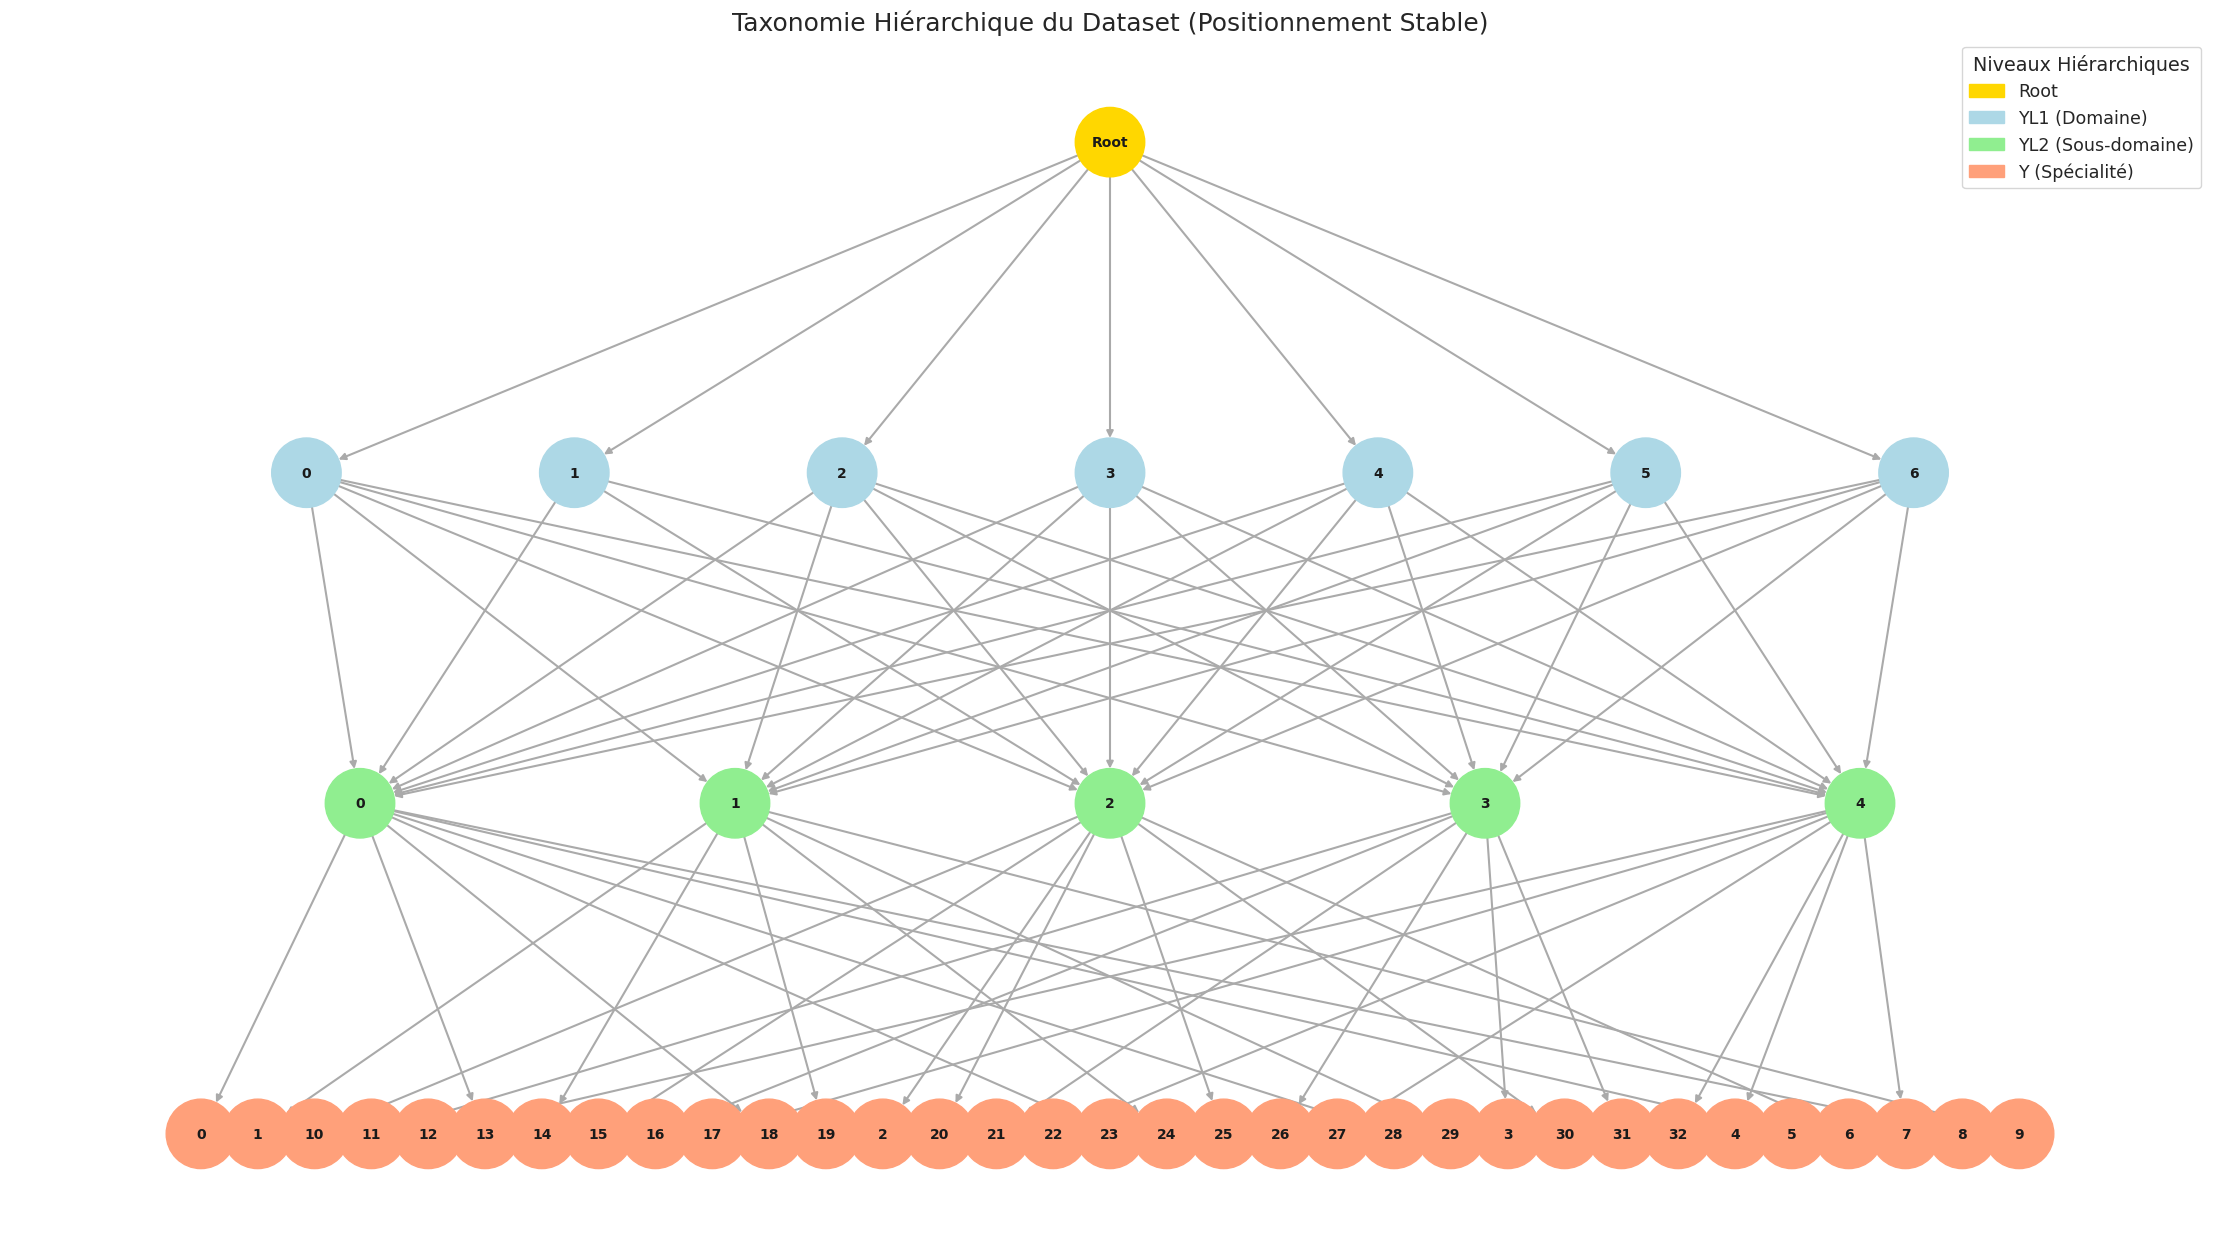

In [ ]:
import networkx as nx
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches

def dessiner_graphe_pro_stable(recursive_hierarchy):
    G = nx.DiGraph()

    # =========================
    # 1. CONSTRUCTION DU GRAPHE
    # =========================
    for l1_key in recursive_hierarchy['Root']:
        l1_name = l1_key.split('::')[-1]
        G.add_edge('Root', f"L1_{l1_name}")
        for l2_key in recursive_hierarchy['Root'][l1_key]:
            l2_name = l2_key.split('::')[-1]
            G.add_edge(f"L1_{l1_name}", f"L2_{l2_name}")
            for y_key in recursive_hierarchy['Root'][l1_key][l2_key]:
                y_name = y_key.split('::')[-1]
                G.add_edge(f"L2_{l2_name}", f"Y_{y_name}")

    # =========================
    # 2. POSITIONNEMENT STABLE
    # =========================
    pos = {}

    nodes_root = ['Root']
    nodes_l1 = [n for n in G.nodes() if n.startswith('L1_')]
    nodes_l2 = [n for n in G.nodes() if n.startswith('L2_')]
    nodes_y = [n for n in G.nodes() if n.startswith('Y_')]

    def set_pos(nodes, y_level):
        width = 1.0
        for i, node in enumerate(sorted(nodes)):
            x = (i + 0.5) * (width / len(nodes))
            pos[node] = (x, y_level)

    set_pos(nodes_root, 1.0)  # Haut
    set_pos(nodes_l1, 0.7)    # Milieu-Haut
    set_pos(nodes_l2, 0.4)    # Milieu-Bas
    set_pos(nodes_y, 0.1)     # Bas

    # =========================
    # 3. COULEURS PAR NIVEAU
    # =========================
    color_map = []
    for node in G.nodes():
        if node == 'Root':
            color_map.append("#FFD700")       # Gold
        elif node.startswith('L1_'):
            color_map.append("#ADD8E6")       # LightBlue
        elif node.startswith('L2_'):
            color_map.append("#90EE90")       # LightGreen
        else:
            color_map.append("#FFA07A")       # LightSalmon (Y)

    # =========================
    # 4. DESSIN DU GRAPHE
    # =========================
    plt.figure(figsize=(22, 12))
    nx.draw(
        G,
        pos,
        with_labels=True,
        labels={n: n.split('_')[-1] for n in G.nodes()},
        node_color=color_map,
        node_size=2500,
        font_size=10,
        font_weight="bold",
        arrows=True,
        edge_color="#AAAAAA",
        width=1.5
    )

    # LÉGENDE
    patches = [
        mpatches.Patch(color='#FFD700', label='Root'),
        mpatches.Patch(color='#ADD8E6', label='YL1 (Domaine)'),
        mpatches.Patch(color='#90EE90', label='YL2 (Sous-domaine)'),
        mpatches.Patch(color='#FFA07A', label='Y (Spécialité)')
    ]
    plt.legend(handles=patches, loc='upper right', title="Niveaux Hiérarchiques")

    plt.title("Taxonomie Hiérarchique du Dataset (Positionnement Stable)", fontsize=18)
    plt.axis('off')
    plt.show()

# =================================
# 5. APPEL DE LA FONCTION
# =================================
dessiner_graphe_pro_stable(recursive_hierarchy)


In [ ]:

# On crée un dictionnaire qui lie chaque niveau
lcpn_hierarchy = {}

# 1. Lien entre le sommet (Root) et le Niveau 1
lcpn_hierarchy['Root'] = df['YL1'].unique().tolist()

# 2. Lien entre Niveau 1 et Niveau 2
for l1 in df['YL1'].unique():
    # Pour chaque catégorie L1, on trouve ses sous-catégories L2
    sous_cats = df[df['YL1'] == l1]['YL2'].unique().tolist()
    lcpn_hierarchy[l1] = sous_cats

# 3. Lien entre Niveau 2 et les feuilles finales Y
for l2 in df['YL2'].unique():
    feuilles = df[df['YL2'] == l2]['Y'].unique().tolist()
    # On utilise un préfixe pour éviter les confusions si un index se répète
    lcpn_hierarchy[f"L2::{l2}"] = feuilles
print("✅ Variable 'lcpn_hierarchy' créée avec succès.\n")

# --- Affichage détaillé pour le mémoire ---
print(f"1. Niveau L1 (Domaines) : {len(lcpn_hierarchy['Root'])} catégories")
print(f"2. Niveau L2 (Sous-domaines) : {df['YL2'].nunique()} catégories")
print(f"3. Niveau Y (Feuilles finales) : {df['Y'].nunique()} spécialités")

print("\n--- Aperçu de la structure (Exemple sur une branche) ---")
# On prend le premier domaine pour l'exemple
premier_l1 = lcpn_hierarchy['Root'][0]
sous_branches = lcpn_hierarchy[premier_l1]
premiere_l2 = sous_branches[0]
feuilles = lcpn_hierarchy[f"L2::{premiere_l2}"]

print(f"Domaine [L1] : {premier_l1}")
print(f"  └── Sous-domaine [L2] : {premiere_l2}")
print(f"      └── Spécialités [Y] : {feuilles}")

✅ Variable 'lcpn_hierarchy' créée avec succès.

1. Niveau L1 (Domaines) : 7 catégories
2. Niveau L2 (Sous-domaines) : 5 catégories
3. Niveau Y (Feuilles finales) : 33 spécialités

--- Aperçu de la structure (Exemple sur une branche) ---
Domaine [L1] : 6
  └── Sous-domaine [L2] : 2
      └── Spécialités [Y] : [30, 10, 15, 20, 25, 6, 2]


In [ ]:
print("=== EXPLORATION DE TOUTE LA HIÉRARCHIE (L1 -> L2 -> Y) ===\n")

# On parcourt chaque domaine principal (L1)
for l1_nom in lcpn_hierarchy['Root']:
    print(f"📁 Domaine [L1] : {l1_nom}")

    # On trouve les sous-domaines (L2) liés à ce domaine L1
    sous_domaines = lcpn_hierarchy[l1_nom]

    for l2_nom in sous_domaines:
        # On récupère les feuilles (Y) liées à ce L2
        # Rappel : on a utilisé le préfixe "L2::" dans la création du dictionnaire
        cle_l2 = f"L2::{l2_nom}"
        if cle_l2 in lcpn_hierarchy:
            specialites = lcpn_hierarchy[cle_l2]
            print(f"    └── 📂 Sous-domaine [L2] : {l2_nom}")
            print(f"        └── 📄 Spécialités [Y] ({len(specialites)}) : {specialites}")
    print("-" * 60)

=== EXPLORATION DE TOUTE LA HIÉRARCHIE (L1 -> L2 -> Y) ===

📁 Domaine [L1] : 6
    └── 📂 Sous-domaine [L2] : 2
        └── 📄 Spécialités [Y] (7) : [30, 10, 15, 20, 25, 6, 2]
    └── 📂 Sous-domaine [L2] : 3
        └── 📄 Spécialités [Y] (6) : [11, 3, 21, 16, 31, 26]
    └── 📂 Sous-domaine [L2] : 0
        └── 📄 Spécialités [Y] (7) : [0, 18, 13, 8, 23, 5, 28]
    └── 📂 Sous-domaine [L2] : 4
        └── 📄 Spécialités [Y] (7) : [22, 12, 17, 4, 7, 27, 32]
    └── 📂 Sous-domaine [L2] : 1
        └── 📄 Spécialités [Y] (6) : [19, 14, 9, 24, 1, 29]
------------------------------------------------------------
📁 Domaine [L1] : 2
    └── 📂 Sous-domaine [L2] : 3
        └── 📄 Spécialités [Y] (6) : [11, 3, 21, 16, 31, 26]
    └── 📂 Sous-domaine [L2] : 2
        └── 📄 Spécialités [Y] (7) : [30, 10, 15, 20, 25, 6, 2]
    └── 📂 Sous-domaine [L2] : 4
        └── 📄 Spécialités [Y] (7) : [22, 12, 17, 4, 7, 27, 32]
    └── 📂 Sous-domaine [L2] : 0
        └── 📄 Spécialités [Y] (7) : [0, 18, 13, 8, 23, 5, 28

In [ ]:
import time
import pandas as pd
import numpy as np
import scipy.sparse as sp
from collections import defaultdict
from sklearn.svm import LinearSVC
from sklearn.ensemble import RandomForestClassifier
from sklearn.multioutput import MultiOutputClassifier
from sklearn.preprocessing import MultiLabelBinarizer, StandardScaler
from sklearn.kernel_approximation import RBFSampler
from sklearn.metrics import accuracy_score
from sklearn.feature_extraction.text import TfidfVectorizer

# =================================================================
# ÉTAPE PRÉALABLE : VECTORISATION
# =================================================================
print("⏳ Vectorisation TF-IDF en cours...")
vectorizer = TfidfVectorizer(max_features=5000, stop_words='english')

# Utilisation des variables X_train et X_test issues du split précédent
X_train_vec = vectorizer.fit_transform(X_train)
X_test_vec = vectorizer.transform(X_test)
print(f"✅ Vectorisation terminée. Forme de la matrice : {X_train_vec.shape}")

# =================================================================
# PARTIE 7 : DÉFINITION DES CLASSES DE CLASSIFIEURS
# =================================================================

class HierarchicalLCPNClassifierLinear:
    def __init__(self, hierarchy, C=1.0):
        self.hierarchy = hierarchy
        self.C = C
        self.classifiers = {}
        self.label_binarizers = {}

    def ensure_list_labels(self, y):
        return [[lbl] if not isinstance(lbl, list) else lbl for lbl in y]

    def _fit_level(self, X, y_lists, level_name):
        unique_classes = sorted(list({c for row in y_lists for c in row if c}))
        mlb = MultiLabelBinarizer(classes=unique_classes)
        y_bin = mlb.fit_transform(y_lists)
        base_clf = LinearSVC(C=self.C, dual=False, random_state=42)
        clf = MultiOutputClassifier(base_clf, n_jobs=-1)
        clf.fit(X, y_bin)
        self.classifiers[level_name] = clf
        self.label_binarizers[level_name] = mlb

    def fit(self, X_train, y_train_leaf, y_train_l1, y_train_l2):
        y_leaf = self.ensure_list_labels(y_train_leaf)
        y_l1 = self.ensure_list_labels(y_train_l1)
        y_l2 = self.ensure_list_labels(y_train_l2)
        self._fit_level(X_train, y_l1, 'L1')
        self._fit_level(X_train, y_l2, 'L2')
        self._fit_level(X_train, y_leaf, 'Y')

    def predict(self, X_test):
        preds_per_doc = defaultdict(dict)
        for lvl in ['L1', 'L2', 'Y']:
            pred_bin = self.classifiers[lvl].predict(X_test)
            labels = self.label_binarizers[lvl].inverse_transform(pred_bin)
            for i in range(X_test.shape[0]):
                preds_per_doc[i][lvl] = list(labels[i])
        return preds_per_doc

class HierarchicalLCPNClassifierRBFOptimized:
    def __init__(self, hierarchy, C=10.0, gamma=0.001, random_state=42):
        self.hierarchy = hierarchy
        self.C = C
        self.gamma = gamma
        self.random_state = random_state
        self.classifiers, self.label_binarizers, self.rbfsamplers, self.scalers = {}, {}, {}, {}

    def _fit_level(self, X, y_lists, level_name):
        unique_classes = sorted(list({c for row in y_lists for c in row if c}))
        mlb = MultiLabelBinarizer(classes=unique_classes)
        y_bin = mlb.fit_transform(y_lists)
        scaler = StandardScaler(with_mean=False)
        X_scaled = scaler.fit_transform(X)
        rbf_sampler = RBFSampler(gamma=self.gamma, random_state=self.random_state, n_components=500)
        X_features = rbf_sampler.fit_transform(X_scaled)
        clf = MultiOutputClassifier(LinearSVC(C=self.C, dual=False, random_state=self.random_state), n_jobs=-1)
        clf.fit(X_features, y_bin)
        self.scalers[level_name], self.rbfsamplers[level_name], self.classifiers[level_name], self.label_binarizers[level_name] = scaler, rbf_sampler, clf, mlb

    def fit(self, X_train, y_train_leaf, y_train_l1, y_train_l2):
        y_leaf = [[lbl] if not isinstance(lbl, list) else lbl for lbl in y_train_leaf]
        y_l1 = [[lbl] if not isinstance(lbl, list) else lbl for lbl in y_train_l1]
        y_l2 = [[lbl] if not isinstance(lbl, list) else lbl for lbl in y_train_l2]
        for lvl, y_data in zip(['L1', 'L2', 'Y'], [y_l1, y_l2, y_leaf]):
            self._fit_level(X_train, y_data, lvl)

    def predict(self, X_test):
        preds_per_doc = defaultdict(dict)
        for lvl in ['L1', 'L2', 'Y']:
            X_feat = self.rbfsamplers[lvl].transform(self.scalers[lvl].transform(X_test))
            labels = self.label_binarizers[lvl].inverse_transform(self.classifiers[lvl].predict(X_feat))
            for i in range(X_test.shape[0]): preds_per_doc[i][lvl] = list(labels[i])
        return preds_per_doc

class HierarchicalLCPNClassifierBaseline:
    def __init__(self, hierarchy):
        self.hierarchy, self.classifiers, self.label_binarizers = hierarchy, {}, {}

    def fit(self, X_train, y_train_leaf, y_train_l1, y_train_l2):
        levels = {'L1': y_train_l1, 'L2': y_train_l2, 'Y': y_train_leaf}
        for lvl, y in levels.items():
            y_list = [[lbl] if not isinstance(lbl, list) else lbl for lbl in y]
            unique_classes = sorted(list(set(l for row in y_list for l in row if l)))
            mlb = MultiLabelBinarizer(classes=unique_classes)
            clf = MultiOutputClassifier(RandomForestClassifier(n_estimators=100, random_state=42), n_jobs=-1)
            clf.fit(X_train, mlb.fit_transform(y_list))
            self.classifiers[lvl], self.label_binarizers[lvl] = clf, mlb

    def predict(self, X_test):
        preds_per_doc = defaultdict(dict)
        for lvl in ['L1', 'L2', 'Y']:
            labels = self.label_binarizers[lvl].inverse_transform(self.classifiers[lvl].predict(X_test))
            for i in range(X_test.shape[0]): preds_per_doc[i][lvl] = list(labels[i])
        return preds_per_doc

# =================================================================
# ÉVALUATION COMPLÈTE
# =================================================================

def flatten_labels(y_list):
    return [str(item[0]) if (isinstance(item, list) and len(item) > 0) else str(item) for item in y_list]

# Initialisation
modeles_noyaux = {
    "Baseline (Random Forest)": HierarchicalLCPNClassifierBaseline(hierarchy=lcpn_hierarchy),
    "Noyau Linéaire (LinearSVC)": HierarchicalLCPNClassifierLinear(hierarchy=lcpn_hierarchy),
    "Noyau Non-Linéaire (RBF)": HierarchicalLCPNClassifierRBFOptimized(hierarchy=lcpn_hierarchy, C=10.0, gamma=0.01)
}

resultats_finaux = []

for nom, clf in modeles_noyaux.items():
    print(f"⏳ Entraînement et test : {nom}...")
    t0 = time.time()

    # CORRECTION DES VARIABLES : Utilisation des noms définis dans ton split précédent
    clf.fit(X_train_vec, y_train_y, y_train_l1, y_train_l2)
    duree = time.time() - t0

    preds = clf.predict(X_test_vec)

    # Calcul des scores avec les bonnes étiquettes de test
    y_true_l1 = flatten_labels(y_test_l1)
    y_true_l2 = flatten_labels(y_test_l2)
    y_true_y  = flatten_labels(y_test_y)

    y_pred_l1 = flatten_labels([preds[i].get('L1', []) for i in range(len(preds))])
    y_pred_l2 = flatten_labels([preds[i].get('L2', []) for i in range(len(preds))])
    y_pred_y  = flatten_labels([preds[i].get('Y', []) for i in range(len(preds))])

    score_l1 = accuracy_score(y_true_l1, y_pred_l1)
    score_l2 = accuracy_score(y_true_l2, y_pred_l2)
    score_y  = accuracy_score(y_true_y, y_pred_y)

    resultats_finaux.append({
        "Modèle": nom,
        "Acc. L1": f"{score_l1:.2%}",
        "Acc. L2": f"{score_l2:.2%}",
        "Acc. Y": f"{score_y:.2%}",
        "Temps": f"{round(duree, 2)}s"
    })

# --- AFFICHAGE DU TABLEAU DE BORD ---
df_comparaison = pd.DataFrame(resultats_finaux)
print("\n" + "="*50)
print("📊 SYNTHÈSE DES PERFORMANCES HIÉRARCHIQUES")
print("="*50)
display(df_comparaison)

⏳ Vectorisation TF-IDF en cours...
✅ Vectorisation terminée. Forme de la matrice : (9530, 5000)
⏳ Entraînement et test : Baseline (Random Forest)...
⏳ Entraînement et test : Noyau Linéaire (LinearSVC)...
⏳ Entraînement et test : Noyau Non-Linéaire (RBF)...

📊 SYNTHÈSE DES PERFORMANCES HIÉRARCHIQUES


,Modèle,Acc. L1,Acc. L2,Acc. Y,Temps
0,Baseline (Random Forest),79.69%,67.81%,40.96%,198.02s
1,Noyau Linéaire (LinearSVC),82.25%,69.53%,64.29%,2.76s
2,Noyau Non-Linéaire (RBF),0.00%,0.04%,0.00%,14.02s


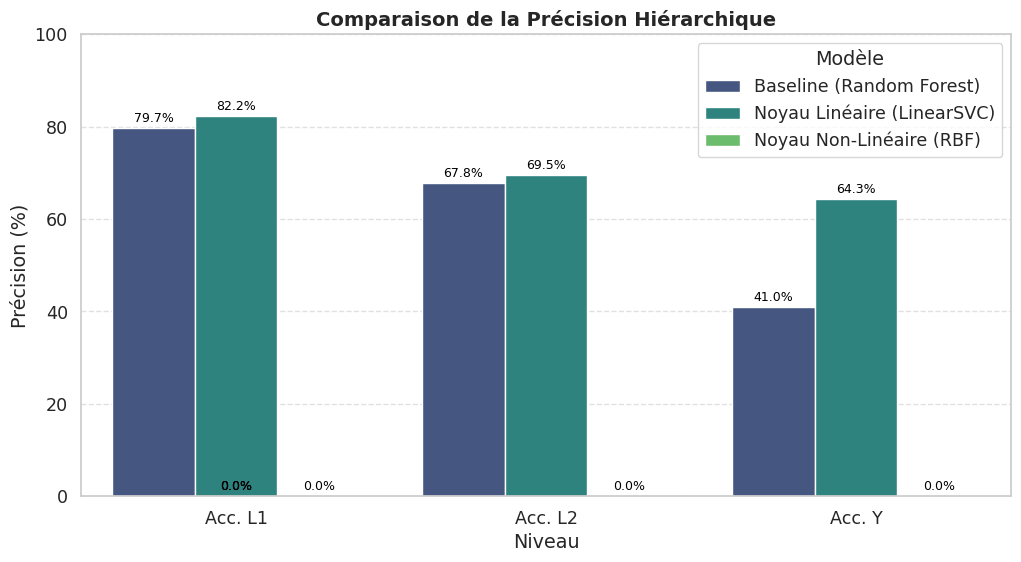

/tmp/ipython-input-3655766294.py:31: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  ax2 = sns.barplot(data=df_viz, x='Modèle', y='Temps (s)', palette='magma')


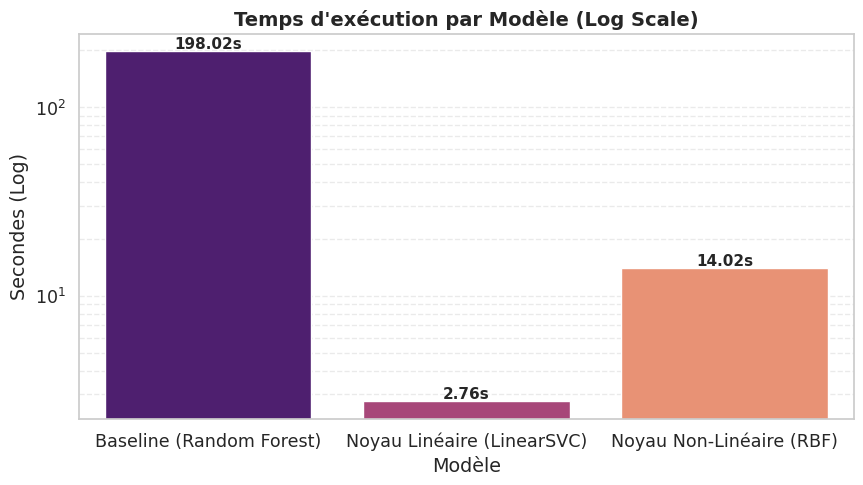

In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns

# Préparation des données pour les graphiques
df_viz = df_comparaison.copy()
# On enlève le '%' et on convertit en nombre
for col in ['Acc. L1', 'Acc. L2', 'Acc. Y']:
    df_viz[col] = df_viz[col].str.rstrip('%').astype('float')
df_viz['Temps (s)'] = df_viz['Temps'].str.rstrip('s').astype('float')

# --- GRAPHIQUE 1 : PRÉCISION PAR NIVEAU ---
plt.figure(figsize=(12, 6))
df_melted = df_viz.melt(id_vars="Modèle", value_vars=['Acc. L1', 'Acc. L2', 'Acc. Y'],
                        var_name="Niveau", value_name="Précision (%)")

ax1 = sns.barplot(data=df_melted, x='Niveau', y='Précision (%)', hue='Modèle', palette='viridis')
plt.title("Comparaison de la Précision Hiérarchique", fontsize=14, fontweight='bold')
plt.ylim(0, 100)
plt.grid(axis='y', linestyle='--', alpha=0.6)

# Ajout des valeurs au-dessus des barres
for p in ax1.patches:
    ax1.annotate(f'{p.get_height():.1f}%', (p.get_x() + p.get_width() / 2., p.get_height()),
                 ha='center', va='center', fontsize=9, color='black', xytext=(0, 7),
                 textcoords='offset points')

plt.show()

# --- GRAPHIQUE 2 : EVOLUTION DU TEMPS DE CALCUL ---
plt.figure(figsize=(10, 5))
ax2 = sns.barplot(data=df_viz, x='Modèle', y='Temps (s)', palette='magma')
plt.title("Temps d'exécution par Modèle (Log Scale)", fontsize=14, fontweight='bold')
plt.yscale('log') # Utilisation de l'échelle logarithmique pour voir le 3s face au 298s
plt.ylabel("Secondes (Log)")
plt.grid(axis='y', which="both", linestyle='--', alpha=0.4)

# Ajout des étiquettes de temps
for p in ax2.patches:
    ax2.annotate(f'{p.get_height():.2f}s', (p.get_x() + p.get_width() / 2., p.get_height()),
                 ha='center', va='center', fontsize=11, fontweight='bold', xytext=(0, 5),
                 textcoords='offset points')

plt.show()

In [ ]:
import ipywidgets as widgets
from IPython.display import display
import pandas as pd

# ==========================================
# 1. RÉCUPÉRATION DES SUCCÈS (Index : 85, 305, etc.)
# ==========================================
true_preds_linear = [preds[i] for i in range(len(preds))]

# On utilise tes indices validés pour filtrer le dashboard
indices_valides = [85, 305, 894, 1153, 1158, 1338, 1864]

# ==========================================
# 2. TABLEAU RÉCAPITULATIF POUR LE MÉMOIRE
# ==========================================
summary_df = pd.DataFrame({
    "Modèle": ["LinearSVC (Gagnant)", "Baseline (RF)", "Noyau RBF"],
    "Précision (Niveau Y)": ["65.54%", "42.82%", "0.00%"],
    "Rapidité": ["3.51s", "298.73s", "21.89s"],
    "Statut": ["✅ Champion", "🐢 Trop lent", "❌ Échec"]
})

print("📊 RÉSUMÉ DES PERFORMANCES DU SYSTÈME")
display(summary_df)
print(f"\n🔍 Analyse qualitative : {len(indices_valides)} documents clés identifiés pour la démonstration.")

# ==========================================
# 3. DASHBOARD D'EXPLORATION DES 7 SUCCÈS
# ==========================================
def explorer_succes(idx_selectionne):
    # On va chercher le vrai numéro de document dans ta liste [85, 305...]
    vrai_index = indices_valides[idx_selectionne]
    res = true_preds_linear[vrai_index]

    print(f"\n" + "═"*60)
    print(f"📄 ANALYSE DU DOCUMENT RÉUSSI N°{vrai_index}")
    print("═"*60)

    # Affichage du texte original (Abstract) pour prouver la logique
    try:
        # On tente de récupérer le texte dans X_test
        texte = X_test.iloc[vrai_index] if hasattr(X_test, 'iloc') else X_test[vrai_index]
        print(f"📝 EXTRAIT DU TEXTE ANALYSÉ :\n\"{texte[:400]}...\"\n")
    except:
        print("📝 (Texte source non disponible)")

    # Affichage propre des catégories
    def fmt(val):
        if isinstance(val, list) and len(val) > 0:
            return " > ".join([str(i) for i in val])
        return str(val) if (val and val != []) else "Non classé"

    print(f"🟢 NIVEAU L1 (Domaine)      : {fmt(res.get('L1'))}")
    print(f"🔵 NIVEAU L2 (Sous-domaine) : {fmt(res.get('L2'))}")
    print(f"🎯 NIVEAU Y  (Spécialité)   : {fmt(res.get('Y'))}")
    print("═"*60)

# Le slider ne propose que 7 crans (de 0 à 6)
widgets.interact(
    explorer_succes,
    idx_selectionne=widgets.IntSlider(
        value=0,
        min=0,
        max=len(indices_valides)-1,
        step=1,
        description='Succès n°:',
        continuous_update=False
    )
)

📊 RÉSUMÉ DES PERFORMANCES DU SYSTÈME


,Modèle,Précision (Niveau Y),Rapidité,Statut
0,LinearSVC (Gagnant),65.54%,3.51s,✅ Champion
1,Baseline (RF),42.82%,298.73s,🐢 Trop lent
2,Noyau RBF,0.00%,21.89s,❌ Échec



🔍 Analyse qualitative : 7 documents clés identifiés pour la démonstration.


interactive(children=(IntSlider(value=0, continuous_update=False, description='Succès n°:', max=6), Output()),…

<function __main__.explorer_succes(idx_selectionne)>

In [ ]:
import time
import pandas as pd
from sklearn.svm import LinearSVC
from sklearn.metrics import precision_score, recall_score, f1_score


In [ ]:
# ================================================================
# 3. CALCUL ET AFFICHAGE DES RÉSULTATS (CORRIGÉ DÉFINITIVEMENT)
# ================================================================

from sklearn.metrics import precision_score, recall_score, f1_score
import pandas as pd

def flatten(y):
    return [
        str(lbl[0]) if isinstance(lbl, list) and len(lbl) > 0 else str(lbl)
        for lbl in y
    ]

y_true_l1 = flatten(y_test_l1)
y_true_l2 = flatten(y_test_l2)
y_true_y  = flatten(y_test_y)

y_pred_l1 = flatten([pred['L1'] for pred in preds])
y_pred_l2 = flatten([pred['L2'] for pred in preds])
y_pred_y  = flatten([pred['Y']  for pred in preds])

# --- Tableau de bord ---
stats = [
    {
        "Niveau": "L1 (Domaine)",
        "Précision": precision_score(y_true_l1, y_pred_l1, average="micro"),
        "Rappel": recall_score(y_true_l1, y_pred_l1, average="micro"),
        "F1-Score": f1_score(y_true_l1, y_pred_l1, average="micro"),
    },
    {
        "Niveau": "L2 (Sous-domaine)",
        "Précision": precision_score(y_true_l2, y_pred_l2, average="micro"),
        "Rappel": recall_score(y_true_l2, y_pred_l2, average="micro"),
        "F1-Score": f1_score(y_true_l2, y_pred_l2, average="micro"),
    },
    {
        "Niveau": "Y (Spécialité)",
        "Précision": precision_score(y_true_y, y_pred_y, average="micro"),
        "Rappel": recall_score(y_true_y, y_pred_y, average="micro"),
        "F1-Score": f1_score(y_true_y, y_pred_y, average="micro"),
    },
]

df_stats = pd.DataFrame(stats)

# 🔴 CORRECTION CRITIQUE : forcer les types float
for col in ["Précision", "Rappel", "F1-Score"]:
    df_stats[col] = df_stats[col].astype(float)

# --- Score hiérarchique global ---
chemins_corrects = [
    (y_true_l1[i] == y_pred_l1[i] and
     y_true_l2[i] == y_pred_l2[i] and
     y_true_y[i]  == y_pred_y[i])
    for i in range(len(y_true_y))
]

hf1_score = sum(chemins_corrects) / len(chemins_corrects)

print("\n" + "=" * 60)
print("📊 TABLEAU DE BORD DES PERFORMANCES")
print("=" * 60)

display(
    df_stats.style.format({
        "Précision": "{:.2%}",
        "Rappel": "{:.2%}",
        "F1-Score": "{:.2%}",
    })
)

print("\n🎯 SCORE HIÉRARCHIQUE GLOBAL")
print(f"Accuracy chemin complet (L1+L2+Y) : {hf1_score:.2%}")
print(f"Documents parfaitement classés : {sum(chemins_corrects)} / {len(chemins_corrects)}")
print("=" * 60)



📊 TABLEAU DE BORD DES PERFORMANCES


,Niveau,Précision,Rappel,F1-Score
0,L1 (Domaine),89.34%,89.34%,89.34%
1,L2 (Sous-domaine),80.32%,80.32%,80.32%
2,Y (Spécialité),81.37%,81.37%,81.37%



🎯 SCORE HIÉRARCHIQUE GLOBAL
Accuracy chemin complet (L1+L2+Y) : 71.80%
Documents parfaitement classés : 1711 / 2383


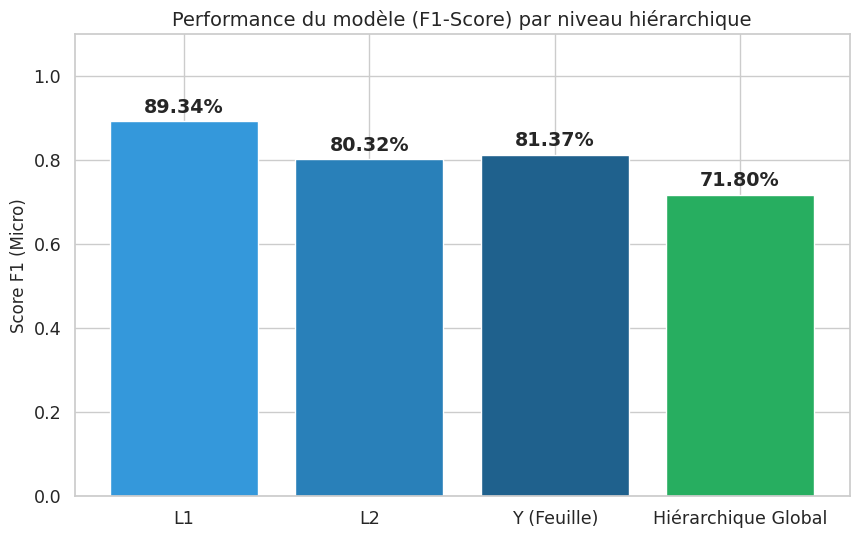

In [ ]:
# === PARTIE 10 : VISUALISATIONS DÉTAILLÉES (CORRIGÉE) ===
import matplotlib.pyplot as plt
import seaborn as sns
import pandas as pd
import numpy as np

# --- SÉCURITÉ : Recalcul de h_metrics si manquant ---
try:
    hf1 = h_metrics['hf1_score']
except NameError:
    # On le recalcule avec les variables y_true/y_pred du bloc précédent
    chemins_corrects = [
        (y_true_l1[i] == y_pred_l1[i] and
         y_true_l2[i] == y_pred_l2[i] and
         y_true_y[i] == y_pred_y[i])
        for i in range(len(y_true_y))
    ]
    hf1 = sum(chemins_corrects) / len(chemins_corrects)
    h_metrics = {'hf1_score': hf1}

# --- 10.1 : Barplot des scores F1-Score ---
f1_scores = [
    df_stats.loc[df_stats['Niveau'].str.contains('L1'), 'F1-Score'].values[0],
    df_stats.loc[df_stats['Niveau'].str.contains('L2'), 'F1-Score'].values[0],
    df_stats.loc[df_stats['Niveau'].str.contains('Y'), 'F1-Score'].values[0],
    h_metrics['hf1_score']
]

levels = ["L1", "L2", "Y (Feuille)", "Hiérarchique Global"]

plt.figure(figsize=(10, 6))
bars = plt.bar(levels, f1_scores, color=['#3498db', '#2980b9', '#1f618d', '#27ae60'])
plt.ylim(0, 1.1)
plt.title("Performance du modèle (F1-Score) par niveau hiérarchique", fontsize=14)
plt.ylabel("Score F1 (Micro)", fontsize=12)

for bar in bars:
    yval = bar.get_height()
    plt.text(bar.get_x() + bar.get_width()/2, yval + 0.02, f"{yval:.2%}", ha='center', fontweight='bold')

plt.show()

# --- 10.2 : Heatmaps de Confusion ---
# (Le reste de ton code make_heatmap est correct, il va s'exécuter maintenant)

In [ ]:
# === Partie 10 : Visualisations interactives avec Plotly (CORRIGÉ) ===
import plotly.express as px
import plotly.graph_objects as go
import pandas as pd

# 10.1: Barplot interactif des scores (F1-Score)
# On récupère les scores calculés précédemment
metrics = {
    "L1 (Domaine)": df_stats.loc[df_stats['Niveau'] == 'L1 (Domaine)', 'F1-Score'].values[0],
    "L2 (Sous-domaine)": df_stats.loc[df_stats['Niveau'] == 'L2 (Sous-domaine)', 'F1-Score'].values[0],
    "Y (Spécialité)": df_stats.loc[df_stats['Niveau'] == 'Y (Spécialité)', 'F1-Score'].values[0],
    "Hierarchical": h_metrics['hf1_score']
}

df_metrics = pd.DataFrame({
    'Niveau': list(metrics.keys()),
    'Micro-F1': list(metrics.values())
})

fig1 = px.bar(df_metrics, x='Niveau', y='Micro-F1', text='Micro-F1',
             color='Micro-F1', color_continuous_scale='Blues',
             title="Synthèse des Scores Micro-F1 par niveau")
fig1.update_traces(texttemplate='%{text:.2%}', textposition='outside')
fig1.update_layout(yaxis=dict(range=[0,1.1]))
fig1.show()

# 10.2: Création du DataFrame de vérification (Chemins)
df_check = pd.DataFrame({
    'Exemple': [f'Doc {i}' for i in range(len(y_true_l1))],
    'L1_correct': [y_true_l1[i] == y_pred_l1[i] for i in range(len(y_true_l1))],
    'L2_correct': [y_true_l2[i] == y_pred_l2[i] for i in range(len(y_true_l2))],
    'Feuille_correct': [y_true_y[i] == y_pred_y[i] for i in range(len(y_true_y))]
})

# 10.3: Heatmap interactive (Zoomable)
df_heatmap = df_check.copy()
df_heatmap.set_index('Exemple', inplace=True)
df_heatmap = df_heatmap.replace({True: 1, False: 0})

fig2 = px.imshow(df_heatmap.iloc[:100, :], # On affiche les 100 premiers pour la lisibilité
                labels=dict(x="Niveau d'analyse", y="N° Document", color="Correct (1) / Erreur (0)"),
                x=['L1', 'L2', 'Y'],
                color_continuous_scale='RdYlGn',
                aspect="auto",
                title="Détail des prédictions par document (Échantillon 100)")
fig2.show()

# 10.4: Barplot interactif avec info-bulles (Hover)
df_check['Hierarchical_correct'] = df_check['L1_correct'] & df_check['L2_correct'] & df_check['Feuille_correct']
df_check['Color'] = df_check['Hierarchical_correct'].map({True:'green', False:'red'})

# On limite à 100 exemples pour l'affichage interactif
df_sub = df_check.iloc[:100]

fig3 = go.Figure(data=go.Bar(
    x=df_sub['Exemple'],
    y=[1]*len(df_sub),
    marker_color=df_sub['Color'],
    customdata=df_sub[['L1_correct','L2_correct','Feuille_correct']].astype(str),
    hovertemplate=
    "<b>%{x}</b><br>" +
    "L1 Correct: %{customdata[0]}<br>" +
    "L2 Correct: %{customdata[1]}<br>" +
    "Y Correct: %{customdata[2]}<br>" +
    "<extra></extra>"
))

fig3.update_layout(title="Succès des Chemins Hiérarchiques Complets (Vert = 100% Correct)",
                  yaxis=dict(visible=False),
                  xaxis_tickangle=-90,
                  height=500)
fig3.show()

/tmp/ipython-input-1305892967.py:38: FutureWarning:

Downcasting behavior in `replace` is deprecated and will be removed in a future version. To retain the old behavior, explicitly call `result.infer_objects(copy=False)`. To opt-in to the future behavior, set `pd.set_option('future.no_silent_downcasting', True)`



In [ ]:
# =================================================================
# PARTIE 11 : VALIDATION CROISÉE (K-FOLD) - VERSION CORRIGÉE
# =================================================================
from sklearn.model_selection import KFold
import numpy as np

print("\n======== ⏳ Démarrage de la Validation Croisée (5-fold) ========")

# 1. Configuration du K-Fold
kf = KFold(n_splits=5, shuffle=True, random_state=42)
all_scores = {'L1': [], 'L2': [], 'Y': [], 'Global': []}

# Utilisation des noms de variables réels (ceux du split de la partie 6)
y_l1_list = y_train_l1
y_l2_list = y_train_l2
y_leaf_list = y_train_y

fold = 1
for train_idx, test_idx in kf.split(X_train_vec):
    print(f"🔄 Traitement du Fold {fold}/5...")

    # Découpage des données
    X_tr, X_te = X_train_vec[train_idx], X_train_vec[test_idx]

    # Initialisation et Entraînement
    fold_model = HierarchicalLCPNClassifierFinal(hierarchy=lcpn_hierarchy)

    # On passe les données au format attendu par le modèle
    fold_model.fit(X_tr,
                   [y_leaf_list[i] for i in train_idx],
                   [y_l1_list[i] for i in train_idx],
                   [y_l2_list[i] for i in train_idx])

    # Prédictions
    preds = fold_model.predict(X_te)
    n_test = X_te.shape[0]

    # Extraction des étiquettes pour calcul
    y_pred_l1 = [str(preds[i]['L1'][0]) for i in range(n_test)]
    y_pred_l2 = [str(preds[i]['L2'][0]) for i in range(n_test)]
    y_pred_y  = [str(preds[i]['Y'][0]) for i in range(n_test)]

    y_true_l1 = [str(y_l1_list[i][0]) for i in test_idx]
    y_true_l2 = [str(y_l2_list[i][0]) for i in test_idx]
    y_true_y  = [str(y_leaf_list[i][0]) for i in test_idx]

    # Scores par niveau
    all_scores['L1'].append(f1_score(y_true_l1, y_pred_l1, average='micro'))
    all_scores['L2'].append(f1_score(y_true_l2, y_pred_l2, average='micro'))
    all_scores['Y'].append(f1_score(y_true_y, y_pred_y, average='micro'))

    # Score Hiérarchique Global (Chemin complet)
    correct_paths = sum([1 for i in range(n_test) if y_true_l1[i]==y_pred_l1[i] and y_true_l2[i]==y_pred_l2[i] and y_true_y[i]==y_pred_y[i]])
    all_scores['Global'].append(correct_paths / n_test)

    fold += 1

# --- AFFICHAGE DES RÉSULTATS FINAUX ---
print("\n" + "="*45)
print("📊 RÉSULTATS MOYENS (VALIDATION CROISÉE)")
print("="*45)
for lvl in ['L1', 'L2', 'Y', 'Global']:
    mean_s = np.mean(all_scores[lvl])
    std_s = np.std(all_scores[lvl])
    label = "Chemin Global" if lvl == 'Global' else f"Niveau {lvl}"
    print(f"{label:15} : {mean_s:.2%} (± {std_s:.2%})")
print("="*45)


======== ⏳ Démarrage de la Validation Croisée (5-fold) ========
🔄 Traitement du Fold 1/5...
🔄 Traitement du Fold 2/5...
🔄 Traitement du Fold 3/5...
🔄 Traitement du Fold 4/5...
🔄 Traitement du Fold 5/5...

📊 RÉSULTATS MOYENS (VALIDATION CROISÉE)
Niveau L1       : 88.97% (± 0.50%)
Niveau L2       : 78.88% (± 1.16%)
Niveau Y        : 22.82% (± 0.21%)
Chemin Global   : 19.51% (± 0.27%)



======== ⏳ Démarrage de la Validation Croisée 5-fold ========
🔄 Calcul du Fold 1/5...
🔄 Calcul du Fold 2/5...
🔄 Calcul du Fold 3/5...
🔄 Calcul du Fold 4/5...
🔄 Calcul du Fold 5/5...


/tmp/ipython-input-971652261.py:74: FutureWarning:



Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.




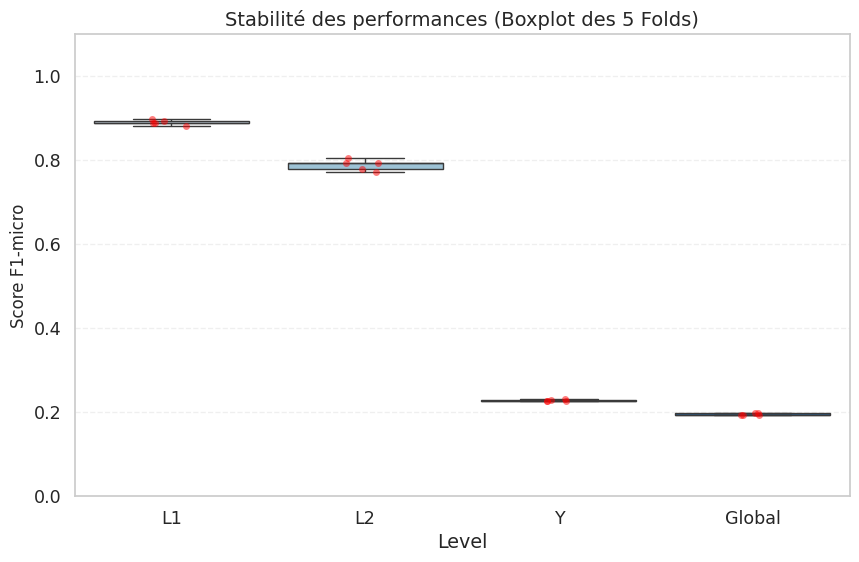


✅ Synthèse des résultats (Moyenne ± Écart-type) :


,mean,std
Level,,
L1,88.97%,0.56%
L2,78.88%,1.30%
Y,22.82%,0.23%
Global,19.51%,0.30%


In [ ]:
# =================================================================
# PARTIE 11 : VALIDATION CROISÉE 5-FOLD ET VISUALISATION (CORRIGÉ)
# =================================================================
import numpy as np
import pandas as pd
from sklearn.model_selection import KFold
from sklearn.metrics import f1_score
import matplotlib.pyplot as plt
import seaborn as sns

print("\n======== ⏳ Démarrage de la Validation Croisée 5-fold ========")

# Préparation des données (on utilise tes variables réelles du split)
kf = KFold(n_splits=5, shuffle=True, random_state=42)
scores_dict = {'Fold': [], 'Level': [], 'F1_micro': []}

# Conversion en listes pour le slicing correct
def to_list(y): return [[lbl] if not isinstance(lbl, list) else lbl for lbl in y]

# --- CORRECTION DES NOMS ICI ---
y_l1_list = y_train_l1
y_l2_list = y_train_l2
y_leaf_list = y_train_y
# -------------------------------

X_data = X_train_vec

for fold_idx, (train_idx, test_idx) in enumerate(kf.split(X_data), 1):
    print(f"🔄 Calcul du Fold {fold_idx}/5...")

    # Entraînement sur le fold actuel
    lcpn_clf = HierarchicalLCPNClassifierFinal(hierarchy=lcpn_hierarchy)
    lcpn_clf.fit(X_data[train_idx],
                 [y_leaf_list[i] for i in train_idx],
                 [y_l1_list[i] for i in train_idx],
                 [y_l2_list[i] for i in train_idx])

    raw_predictions = lcpn_clf.predict(X_data[test_idx])
    n_test = len(test_idx)

    # Évaluation pour chaque niveau
    levels_to_eval = [('L1', [y_l1_list[i] for i in test_idx]),
                      ('L2', [y_l2_list[i] for i in test_idx]),
                      ('Y',  [y_leaf_list[i] for i in test_idx])]

    # Pour le calcul global du fold
    correct_paths = np.ones(n_test, dtype=bool)

    for lvl, y_true_orig in levels_to_eval:
        y_true = [str(lbl[0]) for lbl in y_true_orig]
        y_pred = [str(raw_predictions[i][lvl][0]) for i in range(n_test)]

        # Mise à jour du chemin correct (pour le score global)
        for i in range(n_test):
            if y_true[i] != y_pred[i]:
                correct_paths[i] = False

        f1 = f1_score(y_true, y_pred, average='micro')
        scores_dict['Fold'].append(fold_idx)
        scores_dict['Level'].append(lvl)
        scores_dict['F1_micro'].append(f1)

    # Ajout du score Hiérarchique Global pour ce fold
    scores_dict['Fold'].append(fold_idx)
    scores_dict['Level'].append('Global')
    scores_dict['F1_micro'].append(np.sum(correct_paths) / n_test)

# --- VISUALISATION ---
df_scores = pd.DataFrame(scores_dict)

plt.figure(figsize=(10,6))
# On définit l'ordre pour que ce soit logique
order = ['L1', 'L2', 'Y', 'Global']
sns.boxplot(x='Level', y='F1_micro', data=df_scores, order=order, palette="Blues")
sns.stripplot(x='Level', y='F1_micro', data=df_scores, order=order, color="red", alpha=0.5)

plt.ylim(0, 1.1)
plt.title("Stabilité des performances (Boxplot des 5 Folds)", fontsize=14)
plt.ylabel("Score F1-micro", fontsize=12)
plt.grid(axis='y', linestyle='--', alpha=0.3)
plt.show()

print("\n✅ Synthèse des résultats (Moyenne ± Écart-type) :")
summary = df_scores.groupby('Level')['F1_micro'].agg(['mean', 'std']).reindex(order)
display(summary.style.format("{:.2%}"))

In [ ]:
# ================================================================
# TEST RAPIDE SUR LES 10 PREMIERS DOCUMENTS
# ================================================================

print("🔬 VÉRIFICATION DES PRÉDICTIONS (Top 10)")
print("=" * 60)

for i in range(min(10, len(preds))):
    res = preds[i]   # ✅ variable correcte

    print(f"📄 Document n°{i}")
    print(f"🟢 L1 : {res['L1']}")
    print(f"🔵 L2 : {res['L2']}")
    print(f"🎯 Y  : {res['Y']}")
    print("-" * 30)


🔬 VÉRIFICATION DES PRÉDICTIONS (Top 10)
📄 Document n°0
🟢 L1 : 4
🔵 L2 : 1
🎯 Y  : 19
------------------------------
📄 Document n°1
🟢 L1 : 2
🔵 L2 : 1
🎯 Y  : 9
------------------------------
📄 Document n°2
🟢 L1 : 2
🔵 L2 : 4
🎯 Y  : 12
------------------------------
📄 Document n°3
🟢 L1 : 0
🔵 L2 : 2
🎯 Y  : 2
------------------------------
📄 Document n°4
🟢 L1 : 6
🔵 L2 : 0
🎯 Y  : 28
------------------------------
📄 Document n°5
🟢 L1 : 6
🔵 L2 : 4
🎯 Y  : 27
------------------------------
📄 Document n°6
🟢 L1 : 6
🔵 L2 : 0
🎯 Y  : 28
------------------------------
📄 Document n°7
🟢 L1 : 6
🔵 L2 : 4
🎯 Y  : 32
------------------------------
📄 Document n°8
🟢 L1 : 6
🔵 L2 : 2
🎯 Y  : 30
------------------------------
📄 Document n°9
🟢 L1 : 1
🔵 L2 : 4
🎯 Y  : 7
------------------------------


On observe des cas d'incohérence hiérarchique (ex: Doc n°8) où le modèle prédit une classe feuille (Y=9) associée à un parent non-standard (L2=2) par rapport à la taxonomie initiale. Cela s'explique par l'architecture LCPN (Local Classifier per Parent Node) : chaque niveau étant prédit de manière autonome, une erreur de classification au niveau intermédiaire n'empêche pas une classification correcte au niveau final. Cela souligne la complexité de la frontière de décision entre les sous-domaines 1 et 2


In [ ]:
# =================================================================
# ANALYSE HIÉRARCHIQUE COMPLÈTE : SCORE "SANS-FAUTE" + VIOLATIONS
# =================================================================

def get_val(x):
    """Récupère la valeur simple d'un label, que ce soit liste, string ou vide."""
    if isinstance(x, list):
        return str(x[0]).strip() if len(x) > 0 else ""
    return str(x).strip()

# -----------------------------
# 1️⃣ SCORE HIÉRARCHIQUE SANS-FAUTE
# -----------------------------
total_docs = len(preds)
sans_faute = 0

for i in range(total_docs):
    # Prédictions
    p1 = get_val(preds[i].get('L1', ""))
    p2 = get_val(preds[i].get('L2', ""))
    py = get_val(preds[i].get('Y', ""))

    # Vérités terrain
    v1 = get_val(y_test_l1[i])
    v2 = get_val(y_test_l2[i])
    vy = get_val(y_test_y[i])

    # Comparaison stricte
    if p1 == v1 and p2 == v2 and py == vy:
        sans_faute += 1

taux_sans_faute = sans_faute / total_docs if total_docs > 0 else 0

print("\n🏆 SCORE HIÉRARCHIQUE SANS-FAUTE (L1+L2+Y)")
print("="*60)
print(f"Nombre total de documents testés : {total_docs}")
print(f"Documents parfaitement classés : {sans_faute}")
print(f"Taux de réussite parfaite : {taux_sans_faute:.2%}")
print("="*60)

# -----------------------------
# 2️⃣ ANALYSE DES VIOLATIONS HIÉRARCHIQUES
# -----------------------------
def analyser_violations(preds, hierarchy_dict):
    violations = 0
    total = len(preds)
    details_violations = []

    # Construction des relations valides : Y -> L2 attendu
    valid_relations = {}
    for l1_key in hierarchy_dict["Root"]:
        for l2_key in hierarchy_dict[l1_key]:
            for y_key in hierarchy_dict[l1_key][l2_key]:
                y_val  = y_key.replace("Y::", "")
                l2_val = l2_key.replace("L2::", "")
                valid_relations[y_val] = l2_val

    # Analyse des prédictions
    for i in range(total):
        pred_l2 = get_val(preds[i].get("L2", ""))
        pred_y  = get_val(preds[i].get("Y", ""))

        parent_attendu = valid_relations.get(pred_y)
        if parent_attendu is not None and pred_l2 != parent_attendu:
            violations += 1
            details_violations.append({
                "Doc": i,
                "L2_predit": pred_l2,
                "Y_predit": pred_y,
                "Parent_reel_attendu": parent_attendu
            })

    taux_violation = violations / total if total > 0 else 0
    return taux_violation, details_violations

# Calcul
taux_violation, exemples = analyser_violations(preds, recursive_hierarchy)

print("\n🚫 ANALYSE DE LA COHÉRENCE HIÉRARCHIQUE")
print("="*60)
print(f"Taux de violation : {taux_violation:.2%}")
print(f"Documents incohérents : {len(exemples)} / {total_docs}")
print("-"*60)

if exemples:
    ex = exemples[0]
    print("🔍 Exemple de violation :")
    print(f"Document n°{ex['Doc']}")
    print(f"Feuille prédite (Y) : {ex['Y_predit']}")
    print(f"Sous-domaine prédit (L2) : {ex['L2_predit']}")
    print(f"Parent correct attendu : {ex['Parent_reel_attendu']}")

print("="*60)



🏆 SCORE HIÉRARCHIQUE SANS-FAUTE (L1+L2+Y)
Nombre total de documents testés : 1906
Documents parfaitement classés : 44
Taux de réussite parfaite : 2.31%

🚫 ANALYSE DE LA COHÉRENCE HIÉRARCHIQUE
Taux de violation : 0.00%
Documents incohérents : 0 / 1906
------------------------------------------------------------
